# Setup

In [43]:
# Create the virtual environment
# python -m venv nlp_report

# Activate the environment (Mac/Linux)
# source nlp_report/bin/activate

# Install the Jupyter kernel bridge
# pip install ipykernel

# Register the environment as a Jupyter Kernel
# python -m ipykernel install --user --name=nlp_report --display-name="NLP Propaganda Report"

In [44]:
%pip -q install pandas matplotlib seaborn scikit-learn nltk spacy ollama ipywidgets groq openai numpy dotenv


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
!python -m spacy download en_core_web_sm

^C


In [ ]:
!pip freeze > requirements.txt

# Dataset

## Reading Data

In [237]:
import pandas as pd

# Define your file path
file_path = './propaganda_dataset_v2/propaganda_train.tsv'

# Read the TSV file into a pandas DataFrame
# The sep='\t' argument is crucial here as it tells pandas to split columns by tabs, not commas
df = pd.read_csv(file_path, sep='\t')

# Print a quick summary of the dataframe (row count, null values, data types)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2414 entries, 0 to 2413
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   label              2414 non-null   str  
 1   tagged_in_context  2414 non-null   str  
dtypes: str(2)
memory usage: 37.8 KB


In [238]:
display(df.head())

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won’t make things any worse than they are for President Trump. <EOS>
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen."
3,not_propaganda,"“It looks like we’re capturing the demise of this dark vortex, <BOS> and <EOS> it’s different from what well-known studies led us to expect,” said Michael H. Wong of the University of California at Berkeley says."
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>"


In [239]:
for i in range(3):
    print(df['tagged_in_context'][i])

No, <BOS> he <EOS> will not be confirmed. 
This declassification effort <BOS> won’t make things any worse than they are for President Trump. <EOS> 
The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen. 


## Data Cleaning

Apply cleaning to the full, pre-tokenized sequence. Focus on removing digital artifiacts and variations as these do not refect the language itself.

In [240]:
import html

# Replace all types of line breaks with a space
df['tagged_in_context'] = df['tagged_in_context'].str.replace(r'[\n\r]+', ' ', regex=True)

# Strip leading/trailing whitespace that might be left over
df['tagged_in_context'] = df['tagged_in_context'].str.strip()

# Remove html Artifacts
df['tagged_in_context'] = df['tagged_in_context'].apply(html.unescape)

# Standardize Quotation Marks
def standardize_quotes(text):
    text = text.replace('“', '"').replace('”', '"')
    text = text.replace('‘', "'").replace('’', "'")
    return text

df['tagged_in_context'] = df['tagged_in_context'].apply(standardize_quotes)

# Remove non-ascii characters 
df['tagged_in_context'] = df['tagged_in_context'].str.encode('ascii', 'ignore').str.decode('ascii')

In [241]:
df.head(2)

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>


## Column Unpacking

In [242]:
import nltk
import re

def get_span_indices(text):
    if pd.isna(text) or not isinstance(text, str):
        return (None, None), []
    
    safe_text = text.replace('<BOS>', ' __BOS__ ').replace('<EOS>', ' __EOS__ ')

    raw_tokens = nltk.word_tokenize(safe_text)

    try:
        start_tag_idx = raw_tokens.index('__BOS__')
        end_tag_idx = raw_tokens.index('__EOS__')
    except ValueError:
        # Fallback tracking guard if a row has malformed, single, or missing tags
        clean_tokens = [t for t in raw_tokens if t not in ('__BOS__', '__EOS__')]
        return (None, None), clean_tokens
    
    start_idx = start_tag_idx
    end_idx = end_tag_idx - 2 # storing indices as inclusive is nlp convention is to do (x, y+1) to use

    full_tokens = [t for t in raw_tokens if t not in ('__BOS__', '__EOS__')]

    return (start_idx, end_idx), full_tokens

In [243]:
# Apply the enrichment
df['span_info'] = df['tagged_in_context'].apply(get_span_indices)
df['span_info']

# Unpack for easier EDA
df['span_bounds'] = df['span_info'].apply(lambda x: x[0])
df['all_tokens'] = df['span_info'].apply(lambda x: x[1])

del df['span_info']

df.head(5)

,label,tagged_in_context,span_bounds,all_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]"
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]"
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]"
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]"


## Column Enriching

#### POS Enrichment

In [244]:
import nltk

# Ensure the POS tagger is downloaded
nltk.download('averaged_perceptron_tagger')

def get_pos_list(tokens):
    # nltk.pos_tag returns a list of tuples: [('word', 'TAG'), ...]
    # We only want the tags to keep the column clean for EDA
    tags = [tag for word, tag in nltk.pos_tag(tokens)]
    return tags

# Apply to the already tokenized all_tokens column
df['all_pos_tokens'] = df['all_tokens'].apply(get_pos_list)

# Verify the result
df.head(4)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lukebirkett/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]"
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]"
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, DT, JJ, NN, ,, CC, PRP, VBZ, JJ, IN, WP, JJ, NNS, VBD, PRP, TO, VB, ,, '', VBD, NNP, NNP, NNP, IN, DT, NNP, IN, NNP, IN, NNP, VBZ, .]"


#### Named Entity Tagging

In [245]:
import spacy
from spacy.tokens import Doc
import pandas as pd

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def get_ner_tags_fixed(tokens):
    # Safety Check: If tokens is not a valid list, return an empty list
    if not isinstance(tokens, list):
        return []
        
    # FORCE SPACY TO USE YOUR EXACT NLTK TOKENS
    # This prevents spaCy from re-tokenizing the string and breaking alignments
    doc = Doc(nlp.vocab, words=tokens)
    
    # Run the rest of the spaCy pipeline components (like the NER tagger) over the doc
    for name, proc in nlp.pipeline:
        doc = proc(doc)
        
    # Build your matching 'O' array
    entities = ['O'] * len(tokens)
    
    # Map entities safely onto your exact token array slots
    for ent in doc.ents:
        for i in range(ent.start, ent.end):
            if i < len(entities):
                entities[i] = ent.label_
                
    return entities

In [246]:
# Apply the enrichment safely to the silver dataset, bypassing NaN rows
df['all_ner_tokens'] = df['all_tokens'].apply(
    lambda x: get_ner_tags_fixed(x) if isinstance(x, list) else None
)

df.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]"
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, O]"
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, DT, JJ, NN, ,, CC, PRP, VBZ, JJ, IN, WP, JJ, NNS, VBD, PRP, TO, VB, ,, '', VBD, NNP, NNP, NNP, IN, DT, NNP, IN, NNP, IN, NNP, VBZ, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, PERSON, PERSON, O, ORG, ORG, ORG, ORG, ORG, ORG, O, O]"
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]"


In [247]:
# Check if the number of unique lengths across the three columns is 1 for every row
is_aligned = df.apply(lambda r: len({len(r['all_tokens']), len(r['all_pos_tokens']), len(r['all_ner_tokens'])}) == 1, axis=1)

print(f"✅ All {len(df)} rows aligned!" if is_aligned.all() else f"❌ Mismatches found in {len(df[~is_aligned])} rows")

✅ All 2414 rows aligned!


## EDA

#### Phase 1: Distribution & Sequence EDA

1. [**Class Imbalance Check:**](#1-class-imbalance-check)
2. [**The "Snippet-to-Sentence" Ratio:**](#2-the-snippet-to-sentence-ratio)
3. [**Sequence Length Density:**](#3-sequence-length-density)
4. [**Summary Statistics for Snippet Length:**](#summary-statistics-for-the-snippet-length)
5. [**Summary Statistics for Context Length:**](#summary-statistics-for-the-snippet-length)
6. [**Distribution of Context Left vs Right:**](#6-distribution-of-context-left-vs-right)

---

##### 1. Class Imbalance Check:

Visualize the count of each label and the total data instances. 

###### Code

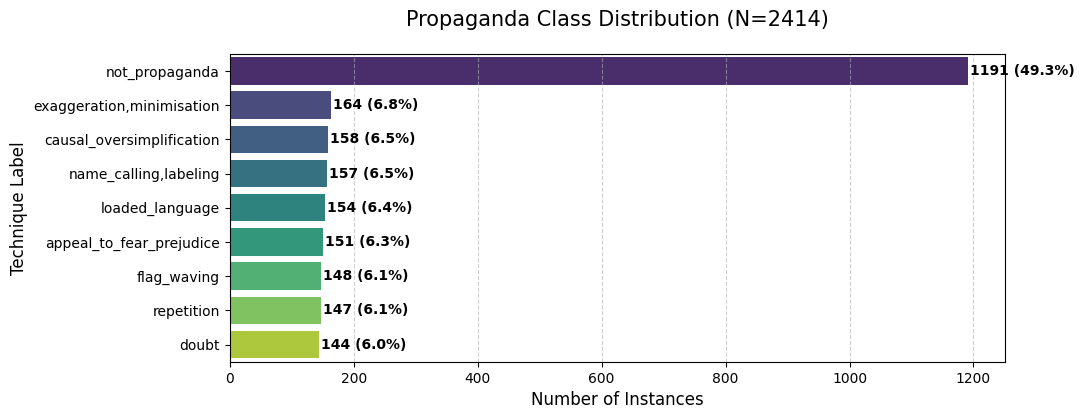

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate counts and percentages
label_counts = df['label'].value_counts()
label_pcts = df['label'].value_counts(normalize=True) * 100

# 2. Plotting
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)

# Add value labels to the end of each bar
for i, v in enumerate(label_counts.values):
    ax.text(v + 3, i, f'{v} ({label_pcts.iloc[i]:.1f}%)', color='black', va='center', fontweight='bold')

plt.title(f'Propaganda Class Distribution (N={len(df)})', fontsize=15, pad=20)
plt.xlabel('Number of Instances', fontsize=12)
plt.ylabel('Technique Label', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Results

- This is important insight for evaluation metric considersations (macro-f1) and loss functions (i.e. Weighted Cross Entropy)
- The dataset is small which each label only around 160 instances. 
- `not_propaganda` is the majorty label making up almost half the instances. Not considered by task 1 but might have impacts for Task 2
- The rest of the classes are remarkably balances which is in contrast to Sem-Eval 2020 task 11 and most propaganda datasets. 
- Impacts goal/desire for silver data creation. Previous had intended to balance the classes but now generation need to be balanced itself to maintin the structure
- Although Macro-F1 should allow fair comparison to the Gold dataset if the silver is imbalanced. 

---

##### 2. The "Snippet-to-Sentence" Ratio:

What percentage of the full_sequence is actually the snippet

*This is a critical metric for understanding the "density" of the propaganda. A low ratio indicates that the propaganda is a small part of a larger, potentially neutral, context (the "needle in a haystack" problem), while a high ratio suggests the propaganda is the primary focus of the sequence.*

###### Code

/var/folders/q9/kmgt4jcs40qbkm14m7p96ld40000gn/T/ipykernel_48154/1128258906.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='snippet_ratio', y='label', palette='mako', order=ratio_stats.index)


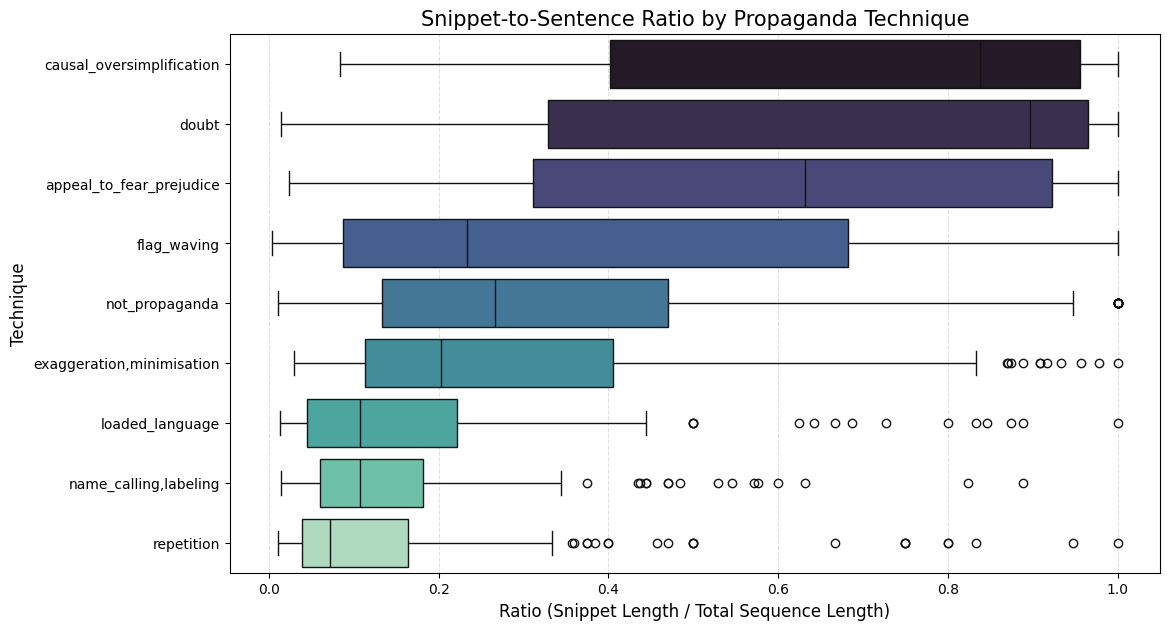

Average Snippet-to-Sentence Ratio per Label:
label
causal_oversimplification    0.698
doubt                        0.685
appeal_to_fear_prejudice     0.594
flag_waving                  0.378
not_propaganda               0.322
exaggeration,minimisation    0.300
loaded_language              0.178
name_calling,labeling        0.159
repetition                   0.158
Name: snippet_ratio, dtype: float64


In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the lengths and the ratio
# Note: x[1] is end_idx, x[0] is start_idx. Span is inclusive, so +1.
df['snippet_token_count'] = df['span_bounds'].apply(lambda x: x[1] - x[0] + 1)
df['total_token_count'] = df['all_tokens'].apply(len)
df['snippet_ratio'] = df['snippet_token_count'] / df['total_token_count']

# 2. Calculate the mean ratio per label for the plot
ratio_stats = df.groupby('label')['snippet_ratio'].mean().sort_values(ascending=False)

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='snippet_ratio', y='label', palette='mako', order=ratio_stats.index)
plt.title('Snippet-to-Sentence Ratio by Propaganda Technique', fontsize=15)
plt.xlabel('Ratio (Snippet Length / Total Sequence Length)', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# 4. Display the average ratio numerically
print("Average Snippet-to-Sentence Ratio per Label:")
print(ratio_stats.round(3))

###### Results

- `causal_oversimplification` (0.698) and `doubt` (0.685) have the highest ratios.
- This means the propaganda makes up the bulk of the sentence.
- This probably tasks 1 harder if we think that the context is valuble.
- But may make Task 2's Span Identifcation easier as the snippet is more defined and there is less substrate (comparatively) to choose from. 
- `repetition` (0.158), `name_calling,labeling` (0.159), and `loaded_language` (0.178) have the lowest ratios.
- This might be a sign that the H1 will hold very strong for some categories.

---

##### 3. Sequence Length Density

Plot the distribution of all_tokens lengths vs. snippet lengths.

###### Code

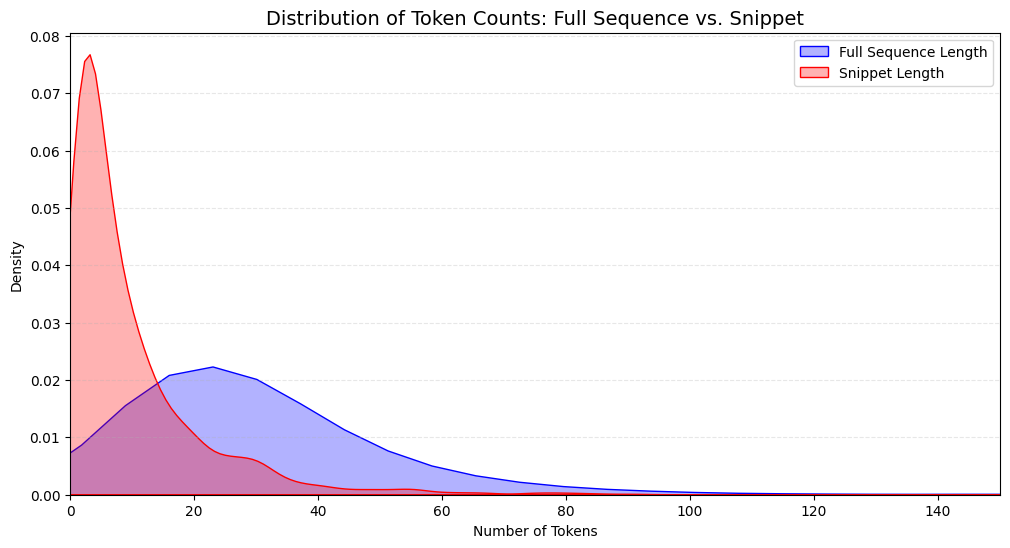

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts for snippet and the full sequence
df['snippet_len'] = df['span_bounds'].apply(lambda x: x[1] - x[0] + 1)
df['full_len'] = df['all_tokens'].apply(len)
df['context_len'] = df['full_len'] - df['snippet_len']

# --- 3. Sequence Length Density Plot ---
plt.figure(figsize=(12, 6))
sns.kdeplot(df['full_len'], label='Full Sequence Length', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df['snippet_len'], label='Snippet Length', fill=True, color='red', alpha=0.3)
plt.title('Distribution of Token Counts: Full Sequence vs. Snippet', fontsize=14)
plt.xlabel('Number of Tokens')
plt.ylabel('Density')
plt.xlim(0, 150) # Clipping for readability, as we know outliers exist
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

###### Results

---

##### 4 & 5: Summary Statistics Tables

###### Code

In [269]:
# --- 4 & 5. Summary Statistics Tables ---
snippet_stats = df.groupby('label')['snippet_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
context_stats = df.groupby('label')['context_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)

print("--- ITEM 4: Snippet Length Statistics ---")
display(snippet_stats.sort_values(by='mean', ascending=False))

print("\n--- ITEM 5: Context Length Statistics ---")
display(context_stats.sort_values(by='mean', ascending=False))

--- ITEM 4: Snippet Length Statistics ---


,count,mean,std,min,max
label,,,,,
causal_oversimplification,158,23.41,15.03,3,86
doubt,144,22.65,20.77,1,160
appeal_to_fear_prejudice,151,18.77,12.86,1,61
flag_waving,148,11.71,14.16,1,79
"exaggeration,minimisation",164,7.95,5.89,1,45
not_propaganda,1191,7.20,7.85,1,91
"name_calling,labeling",157,4.69,3.83,1,24
loaded_language,154,3.76,3.69,1,30
repetition,147,3.07,4.31,1,38



--- ITEM 5: Context Length Statistics ---


,count,mean,std,min,max
label,,,,,
"name_calling,labeling",157,33.64,23.00,1,139
flag_waving,148,32.13,110.67,0,1346
repetition,147,28.15,37.73,0,425
loaded_language,154,27.12,18.11,0,89
"exaggeration,minimisation",164,27.04,19.51,0,85
appeal_to_fear_prejudice,151,20.23,57.65,0,644
not_propaganda,1191,17.81,38.75,0,1285
doubt,144,14.30,22.82,0,134
causal_oversimplification,158,13.98,19.40,0,110


###### Summary Stats with Long Instances Removed

In [270]:
# 1. Create a filtered version of the dataframe
# This excludes the extreme outliers (> 512 tokens)
df_clean = df[df['context_len'] <= 512].copy()

# 2. Run the statistics on the cleaned data
clean_snippet_stats = df_clean.groupby('label')['snippet_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
clean_context_stats = df_clean.groupby('label')['context_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)

# 3. Output results
print(f"Summary Stats (Excluding {len(df) - len(df_clean)} outliers with Context > 512)")

print("\n--- CLEANED Snippet Length Statistics ---")
display(clean_snippet_stats.sort_values(by='mean', ascending=False))

print("\n--- CLEANED Context Length Statistics ---")
display(clean_context_stats.sort_values(by='mean', ascending=False))

Summary Stats (Excluding 3 outliers with Context > 512)

--- CLEANED Snippet Length Statistics ---


,count,mean,std,min,max
label,,,,,
causal_oversimplification,158,23.41,15.03,3,86
doubt,144,22.65,20.77,1,160
appeal_to_fear_prejudice,150,18.79,12.90,1,61
flag_waving,147,11.76,14.20,1,79
"exaggeration,minimisation",164,7.95,5.89,1,45
not_propaganda,1190,7.19,7.85,1,91
"name_calling,labeling",157,4.69,3.83,1,24
loaded_language,154,3.76,3.69,1,30
repetition,147,3.07,4.31,1,38



--- CLEANED Context Length Statistics ---


,count,mean,std,min,max
label,,,,,
"name_calling,labeling",157,33.64,23.00,1,139
repetition,147,28.15,37.73,0,425
loaded_language,154,27.12,18.11,0,89
"exaggeration,minimisation",164,27.04,19.51,0,85
flag_waving,147,23.19,20.70,0,120
not_propaganda,1190,16.74,12.29,0,86
appeal_to_fear_prejudice,150,16.07,26.77,0,283
doubt,144,14.30,22.82,0,134
causal_oversimplification,158,13.98,19.40,0,110


###### Results

- high std for length will impact the class based performance as their it high structural variablilty between the instances. 
- Remove the extra long string reins in the std significantly
- There are a handful of obscently high context length. transfors has a hard limit of 512 but perform more efficently at lower max lengths (i think?).
- When truncating during training will need to devise i way to make sure the snippit isn't truncated. 
- Probably a middle out approach but this risk sacrifing the beginging and end context which for some instances will be the most important. 
- Could look into an augmentation approach if there is enough volumne. 

###### Count Number of Long Context Windows

There are only 3

In [271]:
# 1. Calculate full context length (Left + Right tokens)
# Using our 'all_tokens' and 'span_bounds' logic:
df['context_len'] = df['all_tokens'].apply(len) - (df['span_bounds'].apply(lambda x: x[1] - x[0] + 1))

# 2. Filter for instances exceeding the 512-token limit
long_context_mask = df['context_len'] > 512
long_context_df = df[long_context_mask]

# 3. Print the results
print(f"Total instances with context > 512 tokens: {len(long_context_df)}")

if not long_context_df.empty:
    print("\nBreakdown by Label:")
    print(long_context_df['label'].value_counts())
    
    # Optional: Display the specific rows to see how 'extreme' they are
    display(long_context_df[['label', 'context_len', 'all_tokens']].head())
else:
    print("No instances found exceeding the 512-token threshold.")

Total instances with context > 512 tokens: 3

Breakdown by Label:
label
flag_waving                 1
not_propaganda              1
appeal_to_fear_prejudice    1
Name: count, dtype: int64


,label,context_len,all_tokens
783,flag_waving,1346,"[I, worry, about, this, country, ., not_propaganda, As, St., Paul, declared, ,, ``, Death, is, swallowed, up, in, victory, ., repetition, I, 'm, all, for, situations, like, Nikolas, Cruz, who, assaulted, teachers, and, students, being, arrested, and, tried, and, dealt, with, lawfully, ,, but, to, go, seizing, people, 's, property, and, denying, them, their, liberty, base, on, the, hearsay, of, another, person, is, anti-constitutional, and, anti-American, ., appeal_to_fear_prejudice, Ghost, guns, are, already, a, problem, ;, they, are, used, not, just, by, lone, shooters, but, as, part, of, criminal, enterprises, ., Releasing, instructions, for, their, manufacture, ,, which, now, only, circulate, ...]"
1999,not_propaganda,1285,"[If, we, 're, ready, to, vote, ,, we, will, vote, ,, '', Chairman, Chuck, Grassley, (, R-Iowa, ), tweeted, Tuesday, at, 6:46, p.m., ``, If, we, are, n't, ready, ,, we, wo, n't, ., '', doubt, Would, a, Republican, get, a, pass, on, meeting, with, a, racist, hate, group, leader, ?, not_propaganda, Was, he, violating, God, 's, principles, of, submission, when, he, refused, to, surrender, himself, to, Saul, 's, troops, ?, causal_oversimplification, She, is, a, hijab-wearing, ,, devout, Muslim, ,, and, Islamic, Jew-hatred, is, in, the, Quran, ., not_propaganda, Rhode, Island, not_propaganda, She, is, currently, in, ICE, custody, pending, removal, ...]"
2022,appeal_to_fear_prejudice,644,"[Many, ,, all, too, many, ,, of, them, want, to, overwhelm, German, values, ,, and, European, values, in, general, ,, with, sharia, values, ., flag_waving, America, stands, with, the, people, of, Iran, in, their, courageous, struggle, for, freedom, ., '', loaded_language, Interesting, enough, ,, in, the, Chile, regime-change, operation, ,, the, CIA, and, the, Pentagon, were, telling, their, counterparts, in, the, Chilean, national-security, establishment, that, they, had, a, moral, duty, to, violate, their, nation, 's, constitution, and, violently, remove, their, nation, 's, democratically, elected, president, ,, Salvador, Allende, ,, from, office, ., not_propaganda, Federal, Prosecutors, Called, In, After, Florida, Democrats, ...]"


---

##### 6. Distribution of Context Left vs Right

Do any of the classes exhibit a skew for context on onside? this also tell us if any classes as a bias for the snipper position, i.e. at the end after rhetoric buildup where the context will be very important.

###### Code

--- SEQUENCE ANATOMY: AVERAGE TOKEN COUNTS PER LABEL ---


,left_context_len,snippet_len,right_context_len,Symmetry_Index
label,,,,
"name_calling,labeling",18.68,4.69,14.96,0.56
causal_oversimplification,7.46,23.41,6.53,0.53
doubt,7.30,22.65,7.00,0.51
flag_waving,14.18,11.76,9.01,0.61
"exaggeration,minimisation",15.03,7.95,12.01,0.56
appeal_to_fear_prejudice,9.11,18.79,6.96,0.57
repetition,12.15,3.07,16.00,0.43
loaded_language,15.82,3.76,11.30,0.58
not_propaganda,9.95,7.19,6.79,0.59


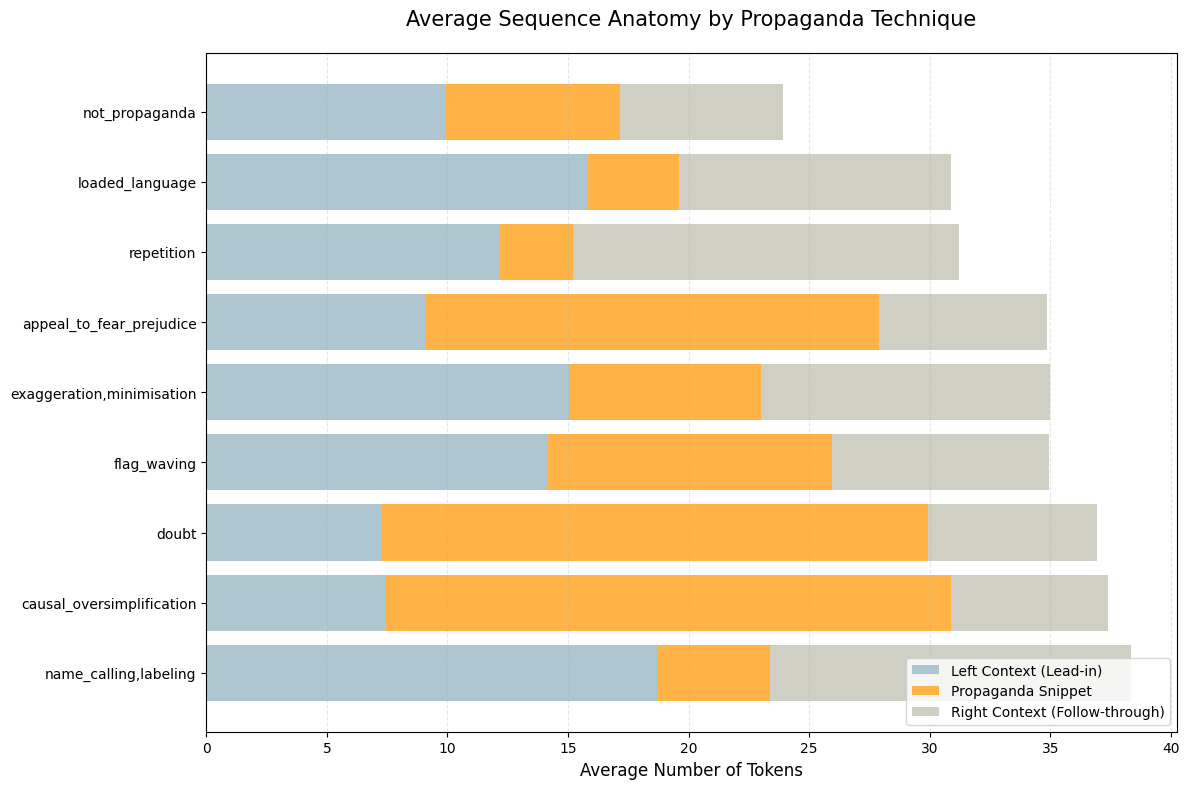

In [272]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean['left_context_len'] = df['span_bounds'].apply(
    lambda x: x[0] if isinstance(x, tuple) and x[0] is not None else 0
)
df_clean['right_context_len'] = df.apply(
    lambda r: len(r['all_tokens']) - (r['span_bounds'][1] + 1) 
    if isinstance(r['span_bounds'], tuple) and r['span_bounds'][1] is not None else 0, 
    axis=1
)

# 1. Aggregate the means per label
comp_data = df_clean.groupby('label')[['left_context_len', 'snippet_len', 'right_context_len']].mean()

# 2. Calculate the Symmetry Index
comp_data['Symmetry_Index'] = (comp_data['left_context_len'] / 
                              (comp_data['left_context_len'] + comp_data['right_context_len'])).round(3)

# 3. Calculate Total Length for sorting
comp_data['Total_Avg_Len'] = comp_data.sum(axis=1)
comp_data = comp_data.sort_values('Total_Avg_Len', ascending=False)

# 4. Display the table for quoting in the report
print("--- SEQUENCE ANATOMY: AVERAGE TOKEN COUNTS PER LABEL ---")
display(comp_data[['left_context_len', 'snippet_len', 'right_context_len', 'Symmetry_Index']].round(2))

# 5. Visualization (Horizontal Stacked Bar)
plt.figure(figsize=(12, 8))
labels = comp_data.index
left = comp_data['left_context_len']
snippet = comp_data['snippet_len']
right = comp_data['right_context_len']

plt.barh(labels, left, color='#aec6cf', label='Left Context (Lead-in)')
plt.barh(labels, snippet, left=left, color='#ffb347', label='Propaganda Snippet')
plt.barh(labels, right, left=left+snippet, color='#cfcfc4', label='Right Context (Follow-through)')

plt.title('Average Sequence Anatomy by Propaganda Technique', fontsize=15, pad=20)
plt.xlabel('Average Number of Tokens', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

$$Symmetry = \frac{Mean\_Left}{Mean\_Left + Mean\_Right}$$
- If $Symmetry \approx 0.5$, the technique is "Context Independent."
- If $Symmetry > 0.6$, the technique is "Narrative-Driven" (needs lead-in).

###### Results

- structurally quite different. this should be good for the span identification. 
    - doubt and casual both balanced and snippet heavy.
    - repetition, loaded, name_called all mid snippet but vary slightly in the skew and composition.
- there are few that are similar in composition which would be good to compare in the analysis to see if the models mis-classify or mis-label.

---

#### Phase 2: Lexical & Morphological EDA (H1 Testing)

7. [**POS Tag Distribution (Heatmap):**](#7-pos-tag-distribution-heatmap)
8. [**Proper Noun Analysis (NER):**](#8-proper-noun-analysis-ner)
9. [**Unique N-Gram Analysis:**](#9-unique-n-gram-analysis)

----

##### 7. POS Tag Distribution (Heatmap):

Compare the frequency of POS tags (JJ, NNP, VB, etc.) within the snippets for each label.

###### Code

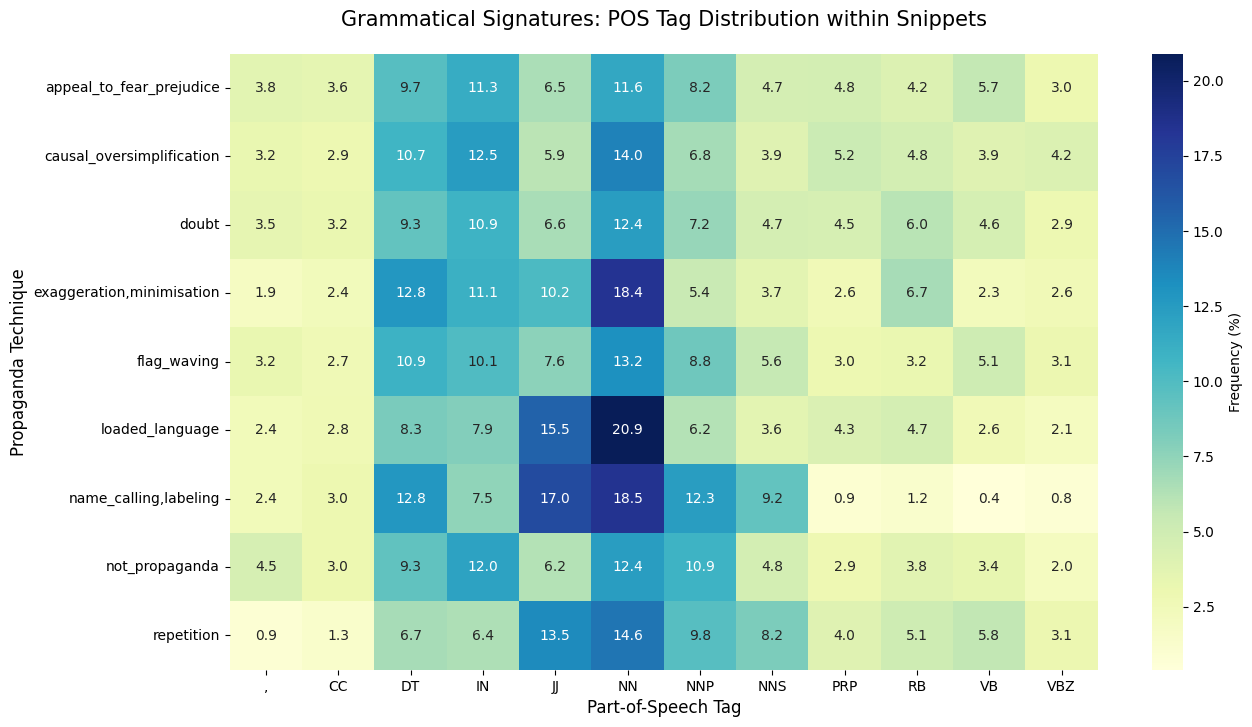

In [273]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the POS tags specifically inside the snippets
def get_snippet_pos(row):
    start, end = row['span_bounds']
    return row['all_pos_tokens'][start : end + 1]

df_clean['snippet_pos'] = df_clean.apply(get_snippet_pos, axis=1)

# 2. Flatten the POS tags by label and count them
pos_by_label = []
for label in df_clean['label'].unique():
    # Combine all POS tags for this label into one long list
    all_tags = [tag for sublist in df_clean[df_clean['label'] == label]['snippet_pos'] for tag in sublist]
    counts = Counter(all_tags)
    total = sum(counts.values())
    
    # Calculate percentage for each tag
    for tag, count in counts.items():
        pos_by_label.append({
            'Label': label,
            'POS_Tag': tag,
            'Frequency (%)': (count / total) * 100
        })

pos_df = pd.DataFrame(pos_by_label)

# 3. Pivot the data for the heatmap
# We'll filter for the most common POS tags to keep the heatmap readable
top_tags = pos_df.groupby('POS_Tag')['Frequency (%)'].sum().sort_values(ascending=False).head(12).index
heatmap_data = pos_df[pos_df['POS_Tag'].isin(top_tags)].pivot(index='Label', columns='POS_Tag', values='Frequency (%)')

# 4. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Frequency (%)'})
plt.title('Grammatical Signatures: POS Tag Distribution within Snippets', fontsize=15, pad=20)
plt.xlabel('Part-of-Speech Tag', fontsize=12)
plt.ylabel('Propaganda Technique', fontsize=12)
plt.show()

--- CONTEXT POS DISTRIBUTION: AVERAGE FREQUENCY PER LABEL ---


POS_Tag,",",.,DT,IN,JJ,NN,NNP,NNS,PRP,RB,VB,VBD
Label,,,,,,,,,,,,
appeal_to_fear_prejudice,5.52,6.31,7.72,10.71,6.18,9.83,10.95,3.69,3.90,3.69,2.99,3.20
causal_oversimplification,5.61,7.51,8.78,11.18,6.07,10.86,9.60,4.93,2.44,3.53,2.49,2.90
doubt,4.95,6.85,9.13,10.83,5.25,12.04,10.68,3.89,2.23,4.23,2.87,3.21
"exaggeration,minimisation",5.37,3.90,9.13,11.93,6.09,11.57,10.13,3.81,3.32,3.50,3.54,3.29
flag_waving,4.63,4.46,8.59,11.12,5.16,10.97,11.21,4.28,2.79,4.28,3.23,2.82
loaded_language,4.31,3.78,9.43,11.37,6.10,11.59,10.87,4.33,2.94,4.24,2.73,2.39
"name_calling,labeling",5.23,3.18,8.63,11.29,5.32,10.91,10.72,3.73,2.97,3.90,3.24,2.73
not_propaganda,4.43,4.57,9.62,10.97,5.35,12.02,11.48,4.50,3.42,3.96,3.18,3.67
repetition,4.62,4.20,9.55,11.19,5.58,12.18,9.30,4.78,3.02,3.46,3.62,3.09


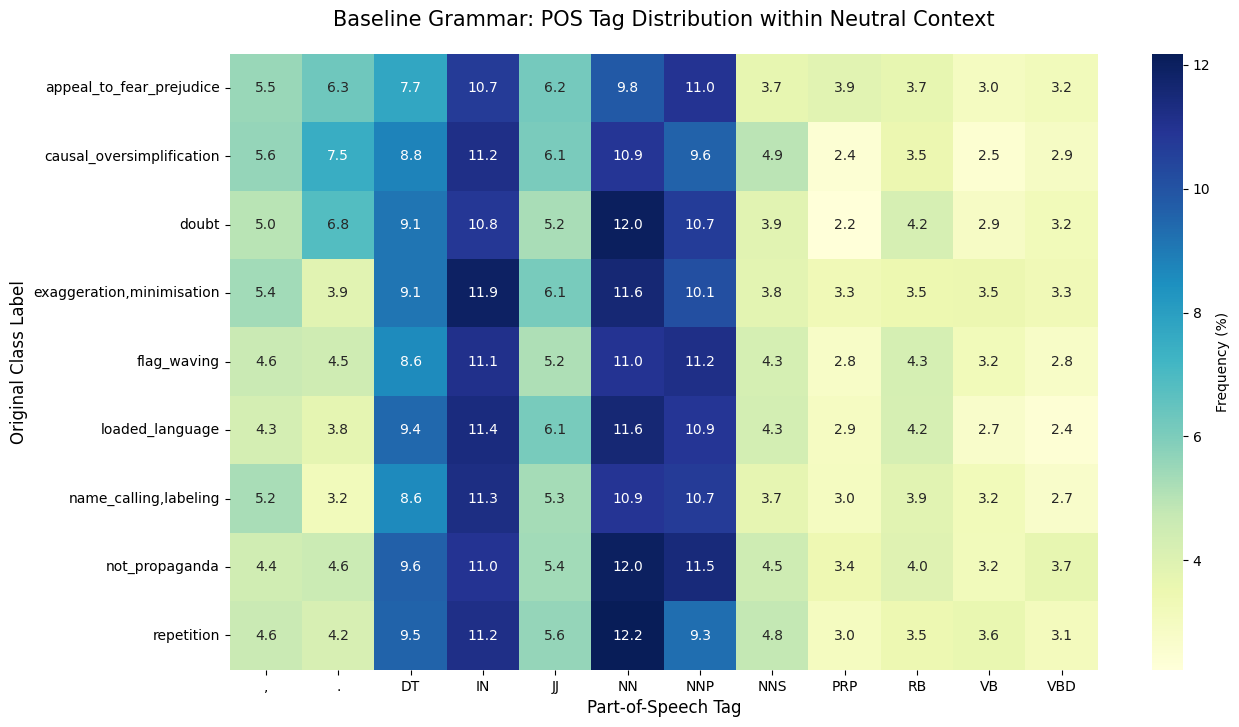

In [274]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the POS tags for the Context (Everything NOT in the span)
def get_context_pos(row):
    start, end = row['span_bounds']
    # Combine tokens from the left and right of the snippet
    return row['all_pos_tokens'][:start] + row['all_pos_tokens'][end + 1:]

df_clean['context_pos'] = df_clean.apply(get_context_pos, axis=1)

# 2. Flatten the POS tags by label and count them
context_pos_data = []
for label in df_clean['label'].unique():
    # Filter for rows with this label and collect context tags
    all_context_tags = [tag for sublist in df_clean[df_clean['label'] == label]['context_pos'] for tag in sublist]
    
    counts = Counter(all_context_tags)
    total = sum(counts.values()) if counts else 1 # Avoid division by zero
    
    for tag, count in counts.items():
        context_pos_data.append({
            'Label': label,
            'POS_Tag': tag,
            'Frequency (%)': (count / total) * 100
        })

context_pos_df = pd.DataFrame(context_pos_data)

# 3. Pivot the data for the heatmap
# Use the same 'top_tags' from the snippet analysis to ensure the comparison is direct
# (Assuming 'top_tags' was defined in the previous cell; if not, we define it here)
top_tags = context_pos_df.groupby('POS_Tag')['Frequency (%)'].sum().sort_values(ascending=False).head(12).index
ctx_heatmap_data = context_pos_df[context_pos_df['POS_Tag'].isin(top_tags)].pivot(index='Label', columns='POS_Tag', values='Frequency (%)')

# 4. Display the table for the report
print("--- CONTEXT POS DISTRIBUTION: AVERAGE FREQUENCY PER LABEL ---")
display(ctx_heatmap_data.round(2))

# 5. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(ctx_heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Frequency (%)'})
plt.title('Baseline Grammar: POS Tag Distribution within Neutral Context', fontsize=15, pad=20)
plt.xlabel('Part-of-Speech Tag', fontsize=12)
plt.ylabel('Original Class Label', fontsize=12)
plt.show()

###### Results

- the context POS for all labels is very consistent and similar thoughout. mostly nn, nnp, in and dt
- the snippets themselves are distributes wildly differently to the context
- firstly, this is important for task 2 because it means propaganda snippets should be clearly identifable and they are structually different to their surroundings. 
- secondly, the pos distributing is different between labels and within tags. 
- nn is still the most freq but there is a wide disparity within going from 20 to 10
- there are some deep categories for jj
- in and dt were very consistent for context but vary for snippet
- there are not . in the snippets meaning it does not occur at the every end of the sentence or accross sentences. 
- nnp its not clear definied as a strong category in the snippers where as it is top 4 in context. 
- rb and nns unique for some labels in snippet

---

##### 8. Proper Noun Analysis (NER):

Identify which entities (PERSON, ORG, GPE) appear most often within snippets.

###### code

"Unlike the POS analysis, which measures token-level distribution, the NER analysis measures Instance-level Presence. A score of 52.78% for 'PERSON' in the 'doubt' category indicates that over half of all snippets of this type target a specific individual. The non-summation to 100% reflects the fact that snippets may target multiple entity types simultaneously or contain no recognized entities at all."

--- NER ENTITY DENSITY: % OF SNIPPETS CONTAINING ENTITY TYPE ---


Entity,EVENT,FAC,GPE,NORP,ORG,PERSON,PRODUCT
Label,,,,,,,
appeal_to_fear_prejudice,2.00,0.00,42.67,29.33,42.00,16.67,0.00
causal_oversimplification,0.00,0.63,27.22,18.99,45.57,49.37,0.63
doubt,0.00,1.39,18.06,14.58,53.47,55.56,0.00
"exaggeration,minimisation",1.83,0.00,5.49,6.10,16.46,9.15,0.00
flag_waving,0.00,0.00,32.65,46.26,21.09,9.52,0.00
loaded_language,0.00,0.00,2.60,2.60,5.19,4.55,0.00
"name_calling,labeling",0.00,1.91,8.28,13.38,18.47,17.20,0.00
not_propaganda,0.08,0.67,12.61,6.39,31.34,20.08,0.42
repetition,0.00,1.36,1.36,2.04,5.44,7.48,0.68


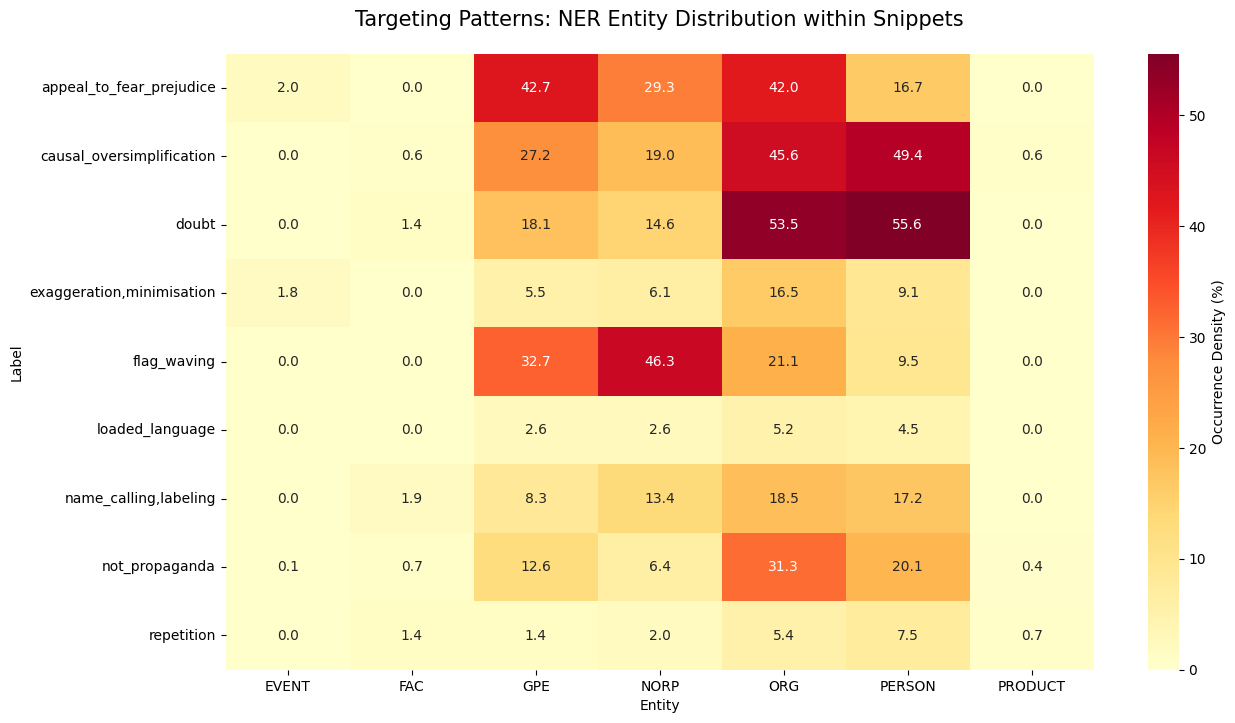

In [275]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the NER tags specifically inside the snippets
def get_snippet_ner(row):
    start, end = row['span_bounds']
    # Return unique entities found in the snippet (excluding 'O')
    return [tag for tag in row['all_ner_tokens'][start : end + 1] if tag != 'O']

df_clean['snippet_ner'] = df_clean.apply(get_snippet_ner, axis=1)

# 2. Calculate the "Entity Presence" per label
ner_stats = []
for label in df_clean['label'].unique():
    label_df = df_clean[df_clean['label'] == label]
    total_instances = len(label_df)
    
    # Count how many snippets in this label contain at least one of each entity type
    all_tags_in_label = [tag for sublist in label_df['snippet_ner'] for tag in sublist]
    tag_counts = Counter(all_tags_in_label)
    
    for tag, count in tag_counts.items():
        ner_stats.append({
            'Label': label,
            'Entity': tag,
            'Density (%)': (count / total_instances) * 100
        })

ner_df = pd.DataFrame(ner_stats)

# 3. Pivot for the heatmap
# We'll focus on the most relevant entities for propaganda analysis
target_entities = ['PERSON', 'ORG', 'GPE', 'NORP', 'FAC', 'PRODUCT', 'EVENT']
heatmap_ner = ner_df[ner_df['Entity'].isin(target_entities)].pivot(index='Label', columns='Entity', values='Density (%)').fillna(0)

# 4. Display numerical table for the report
print("--- NER ENTITY DENSITY: % OF SNIPPETS CONTAINING ENTITY TYPE ---")
display(heatmap_ner.round(2))

# 5. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_ner, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Occurrence Density (%)'})
plt.title('Targeting Patterns: NER Entity Distribution within Snippets', fontsize=15, pad=20)
plt.show()

###### results

##### 9. Unique N-Gram Analysis:

What are the top 2-word or 3-word phrases that only appear in specific propaganda classes? This probably wont be possible given the lack of data in each class but failure to produce good bi-grams or tri-grams means that such techniques will not be justifable later in the modelling phases, so important to highlight this now.

#### Phase 3: Structural & Positional EDA (H2 Testing)


10. [**Relative Position Analysis:**](#10-relative-position-analysis)

---

##### 10. Relative Position Analysis

Calculate start_idx / len(all_tokens). Plot this for each label.

###### code

$$\text{Relative Position} = \frac{\text{Start Index of Snippet}}{\text{Total Token Count of Sequence}}$$
- 0.0: Snippet starts at the very beginning of the sentence.
- 0.5: Snippet starts exactly in the middle.
- 1.0: Snippet is at the very end.

/var/folders/q9/kmgt4jcs40qbkm14m7p96ld40000gn/T/ipykernel_48154/1677862600.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='rel_position', y='label', palette='vlag', whis=np.inf)


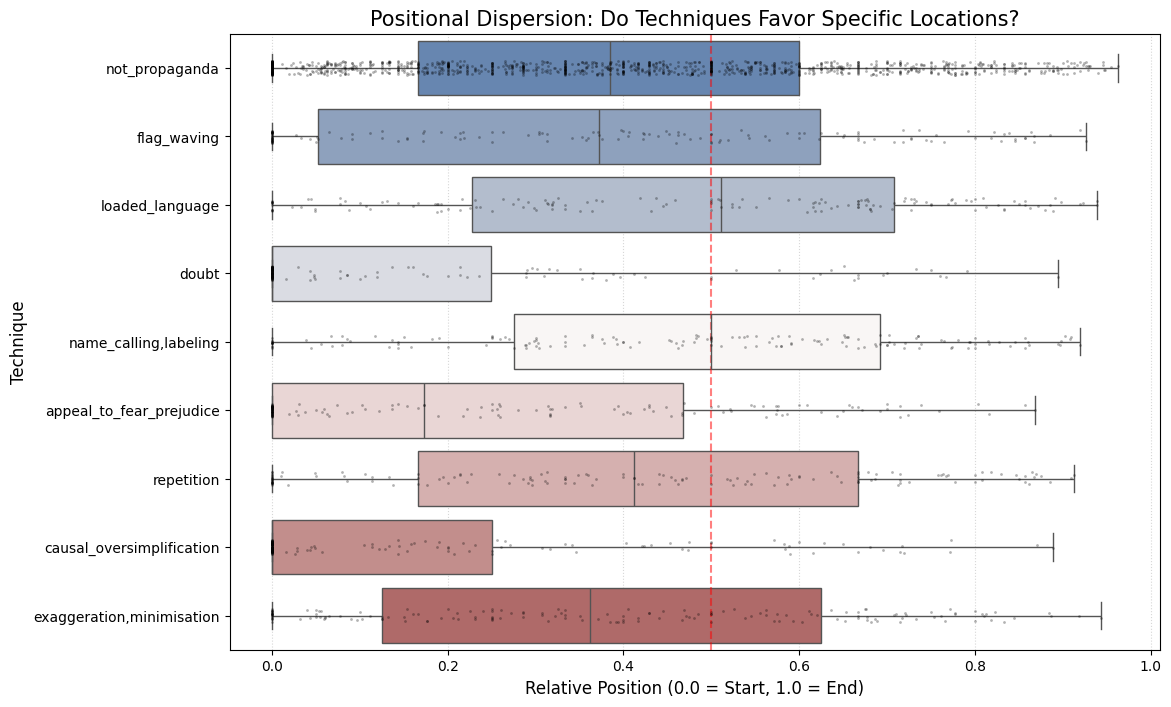

--- POSITIONAL DISPERSION TABLE ---


,mean,std,min,max
label,,,,
flag_waving,0.371,0.296,0.0,0.927
repetition,0.412,0.288,0.0,0.913
loaded_language,0.473,0.285,0.0,0.939
"exaggeration,minimisation",0.381,0.276,0.0,0.943
"name_calling,labeling",0.472,0.269,0.0,0.920
not_propaganda,0.394,0.268,0.0,0.962
appeal_to_fear_prejudice,0.254,0.264,0.0,0.868
causal_oversimplification,0.159,0.237,0.0,0.889
doubt,0.149,0.236,0.0,0.895


In [277]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Relative Position
# (Start Index / Total Tokens)
df_clean['rel_position'] = df_clean['span_bounds'].apply(lambda x: x[0]) / df_clean['all_tokens'].apply(len)

# 2. Visualizing the "Stretch" with a Strip Plot + Box Plot
plt.figure(figsize=(12, 8))

# Boxplot shows the quartiles and medians
sns.boxplot(data=df_clean, x='rel_position', y='label', palette='vlag', whis=np.inf)

# Strip plot shows every single data point to visualize the "stretch"
sns.stripplot(data=df_clean, x='rel_position', y='label', color="black", size=2, alpha=0.3)

plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Sentence Middle')
plt.title('Positional Dispersion: Do Techniques Favor Specific Locations?', fontsize=15)
plt.xlabel('Relative Position (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()

# 3. Calculate the "Dispersion" (Standard Deviation)
# High SD = "Stretch" (The technique can happen anywhere)
# Low SD = "Fixed" (The technique has a preferred location)
position_dispersion = df_clean.groupby('label')['rel_position'].agg(['mean', 'std', 'min', 'max']).round(3)
print("--- POSITIONAL DISPERSION TABLE ---")
display(position_dispersion.sort_values(by='std', ascending=False))

###### results

- definetly seems to be a bias towards starting early. 
- this could a be bias in the data collection itself, or a demonstration of the nuance of prop, as recipients may not realise it is happening at first.
- loaded_language is a clear outlier in the that is occur on average after the 0.5 middle
- name_called also exactly 0.5
- all of the rest of left skewed. 
- doubt, pred, and oversimple actually have their interquarile touching 0. 
- all have pretty consistent std meaning they are predictable within their own labels.

#### Phase 4: Correlation & Complexity

11. **Label Confusion (Theoretical):** Identify which labels share the most common words/POS tags.

---

##### 11. **Label Confusion (Theoretical):**

"By calculating the Theoretical Confusion, you are essentially identifying which labels look the same to a computer. If two labels have a 95% similarity in their POS and vocabulary, you can predict before training that your model will struggle to distinguish them."

###### code

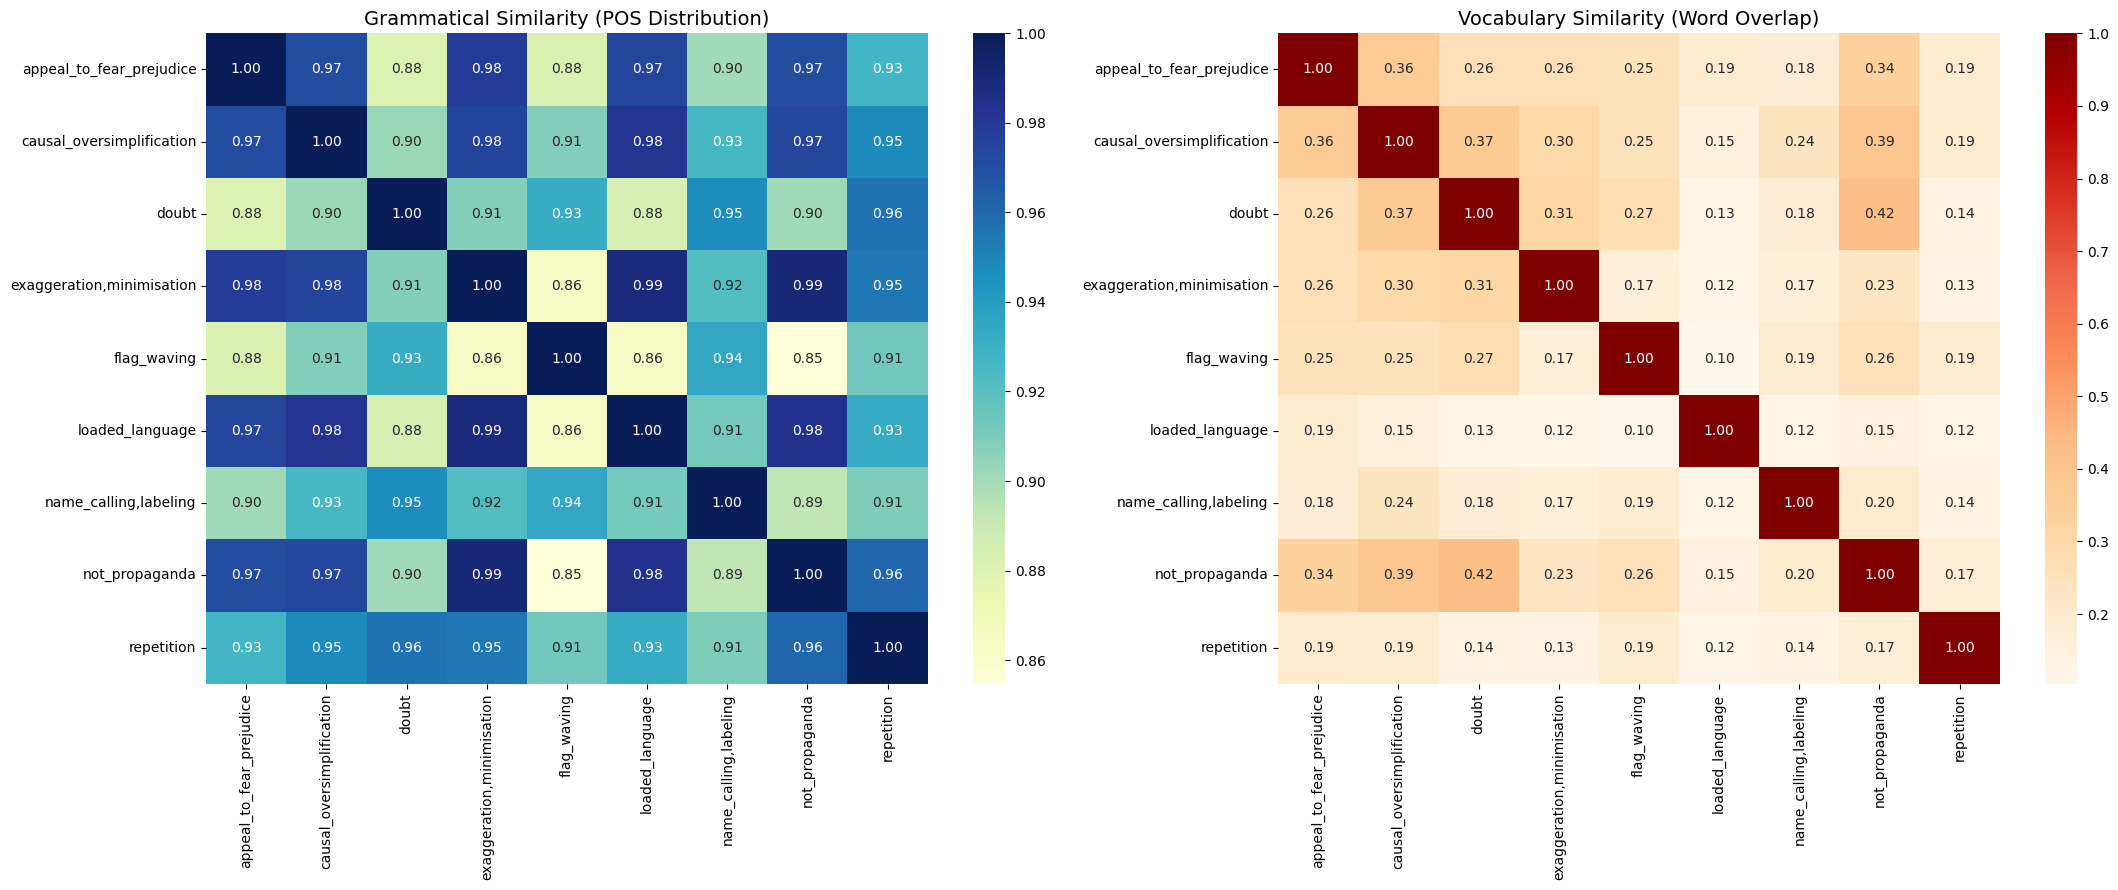

In [278]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Extraction Layer: Slicing snippets from the enriched sequences
# We use span_bounds (start, end) to pull exactly what the model will 'see'
def get_snippet_data(row):
    start, end = row['span_bounds']
    # Slicing is inclusive of the end index
    tokens = row['all_tokens'][start : end + 1]
    pos_tags = row['all_pos_tokens'][start : end + 1]
    return " ".join(tokens), pos_tags

# Create temporary columns for the analysis
# Use df_clean if you are working with the length-filtered dataset
df_analysis = df.copy() 
df_analysis[['snippet_text', 'snippet_pos']] = df_analysis.apply(
    lambda r: pd.Series(get_snippet_data(r)), axis=1
)

# 2. Morphological Similarity (POS Tags)
pos_profiles = []
unique_labels = df_analysis['label'].unique()

for label in unique_labels:
    # Flatten all snippet POS tags for this specific label
    all_tags = [tag for sublist in df_analysis[df_analysis['label'] == label]['snippet_pos'] for tag in sublist]
    counts = Counter(all_tags)
    total = sum(counts.values()) if counts else 1
    # Create a normalized distribution (0.0 to 1.0)
    profile = {tag: (count/total) for tag, count in counts.items()}
    profile['label'] = label
    pos_profiles.append(profile)

pos_dist_df = pd.DataFrame(pos_profiles).set_index('label').fillna(0)
pos_sim_matrix = cosine_similarity(pos_dist_df)

# 3. Lexical Similarity (Vocabulary)
# We treat all snippets of a label as one giant document
label_docs = df_analysis.groupby('label')['snippet_text'].apply(lambda x: " ".join(x.astype(str)))
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(label_docs)
lex_sim_matrix = cosine_similarity(tfidf_matrix)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# POS Heatmap: Stylistic Overlap
sns.heatmap(pos_sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=label_docs.index, yticklabels=label_docs.index, ax=ax1)
ax1.set_title('Grammatical Similarity (POS Distribution)', fontsize=14)

# Lexical Heatmap: Word Overlap
sns.heatmap(lex_sim_matrix, annot=True, fmt=".2f", cmap='OrRd',
            xticklabels=label_docs.index, yticklabels=label_docs.index, ax=ax2)
ax2.set_title('Vocabulary Similarity (Word Overlap)', fontsize=14)

plt.tight_layout()
plt.show()

###### results

---

#### Dataset Artifact Cleanup

In [280]:
del df['snippet_token_count']
del df['total_token_count']
del df['snippet_ratio']
del df['snippet_len']
del df['full_len']
del df['context_len']

In [281]:
df.head(3)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]"
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, O]"
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]"


---

# Data Augmentation

- Few-Short Prompting (In-Context Learning)
- The LLM just needs a well-crafted instruction, not a weight update
- Either reword the snippet only or try to reword the the whole sequence but will need to be able retain the tags. 
- Hallucinations will need to be checked for
- Targetted Substitution or Rephrasing
- Do not need to account for non-propaganda class
- Prompt needs to be contrained to get the correct output
- Can manually set tempurature of model
- Chain-of-Thought (CoT) Contextualization.
- Step-by-step to ensure new snippet makes sense
- Mimicking the way a human linguist works: first coming up with a strong idea, and then refining it to ensure it fits the surrounding puzzle pieces.
- Chained Multi-Prompt Data Augmentation

1. Just supply the prompt with the snippet and ask it to suggest a synonym or a rhetorically similar phrase. Ask it to think out loud out and explain its thoughts step by step
2. Take the output of that prompt and pass it to the next prompt as context. But this time add the prefix. Ask it to review its decision and see it it thinks the output still makes sense, if given the pre-fix context it doesn't, then provide a new snippet that it does. Again ask it to think step-by-step
3. Next, repeat step 2 but with the additional of the suffix. 
4. The final step is to provide the model will all this context and ask it to output its suggested new snippet. This last part needs to be strongly structured. When we can use python f-strings to input the new snippet into the sequence between the existing tags

Cannot reasonably using label definition in prompt as it will encourage the model to belive that it is being used to generate propaganda. may have to remove label as well. 

The snippet has been categorized with the label {label} which is defined as: {label_definition}

label_definition = "Using derogatory labels to attack a person or group."

## Silver Dataset Generative Process

### Ollama Terminal

In [73]:
# Download and install Ollama from ollama.com.

# !ollama run llama3

# !pip install ollama


# ollama pull dolphin-llama3

# https://ollama.com/library/dolphin-llama3

# dolphin-llama3:8b
# dolphin-llama3:70b

# ollama run dolphin-llama3:8b-256k
# >>> /set parameter num_ctx 256000

# response = ollama.chat(
        #     model='dolphin-llama3',  # <-- UPDATE THIS STRING HERE
        #     messages=messages,
        #     options={
        #         'temperature': temperature,
        #         'num_predict': 512,  
        #         'num_thread': 4,     
        #     }
        # )

# https://console.groq.com/home



### Logger

In [91]:
import logging
import sys

# 1. Initialize a named logger (Leave global level at INFO so it captures everything)
logger = logging.getLogger("propaganda_logger")
logger.setLevel(logging.INFO)

# 2. Clear out any existing handlers (prevents duplicate logs when rerunning cells)
if logger.hasHandlers():
    logger.handlers.clear()

# 3. Create a File Handler (Saves EVERYTHING to your text file)
file_handler = logging.FileHandler("propaganda_augmentation.log", mode="a", encoding="utf-8")
file_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
file_handler.setFormatter(file_formatter)
file_handler.setLevel(logging.INFO) # <--- Force the file to capture every single log trace
logger.addHandler(file_handler)

# 4. Create a Stream Handler (Controls live notebook console printing)
stream_handler = logging.StreamHandler(sys.stdout)
stream_formatter = logging.Formatter('%(message)s') 
stream_handler.setFormatter(stream_formatter)

# --- THE BIG RUN FIX ---
# Raise this to WARNING or ERROR. This tells the screen: 
# "Only interrupt my notebook if a row crashes or an API error occurs. Otherwise, stay quiet."
stream_handler.setLevel(logging.WARNING) 
logger.addHandler(stream_handler)

print("Logging system optimized for Batch Run! Detailed transcripts -> 'propaganda_augmentation.log'")

Logging system optimized for Batch Run! Detailed transcripts -> 'propaganda_augmentation.log'


### Call Model Helper Function(s)

In [75]:
# import ollama
# from typing import Optional

# def call_llama(messages: list, temperature: float = 0.7) -> str:
#     """Helper function to call local Llama 3 and return the text content."""
    # try:
    #     response = ollama.chat(
    #         model='dolphin-llama3', 
    #         messages=messages,
    #         options={
    #             'temperature': temperature,
    #             # 'num_predict': 512,  # Caps output length
    #             # 'num_thread': 4,     # Hard-codes execution cores
    #         }
    #     )
    #     return response['message']['content'].strip()
    # except Exception as e:
    #     print(f"Ollama Connection Error: {e}")
    #     return ""

In [ ]:
# from groq import Groq

# # Initialize client with your free API key
# groq_client = Groq(api_key="GROQ_KEY")

# def call_llama(messages: list, temperature: float = 0.7) -> str:
#     """Routes your exact same loop through Groq's blazing fast cloud hardware"""
#     try:
#         response = groq_client.chat.completions.create(
#             model='llama-3.1-8b-instant', 
#             messages=messages,
#             temperature=temperature,
#         )
#         return response.choices[0].message.content.strip()
#     except Exception as e:
#         print(f"Groq API Cloud Error: {e}")
#         return ""

In [77]:
from openai import OpenAI

import os
from dotenv import load_dotenv

# 1. This reads the hidden text file and injects the variables into system memory
load_dotenv()

# 2. This pulls the key string safely out of system memory
together_key = os.getenv("TOG_API_KEY")

# 3. Double check it worked (it shouldn't be None)
if together_key:
    print("[SUCCESS] API Key loaded into notebook background environment memory.")
else:
    print("[ERROR] Could not find TOGETHER_API_KEY. Check your .env file location!")



client = OpenAI(
    api_key=together_key,
    base_url="https://api.together.xyz/v1"  # This one line redirects the traffic!
)

def call_llama(messages: list, temperature: float = 0.7) -> str:

    try:
        response = client.chat.completions.create(
            model="meta-llama/Meta-Llama-3-8B-Instruct-Lite", # together naming 
            # model="openai/gpt-oss-20b", 

            messages=messages,
            temperature=temperature,
            # max_tokens=512
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Cloud API Error: {e}")
        return ""

[SUCCESS] API Key loaded into notebook background environment memory.


### Output Extract Helper Function

In [78]:
import re

def extract_final_snippet(llm_output):
    """
    Tiered extraction to find the final snippet, handling LLM hallucinations.
    """
    if not llm_output:
        return ""

    # Tier 1: Strict Tags
    strict_pattern = r"<final_snippet>(.*?)</final_snippet>"
    strict_matches = re.findall(strict_pattern, llm_output, re.DOTALL | re.IGNORECASE)
    if strict_matches:
        return strict_matches[-1].strip()

    # Tier 2: Broken Tags Fallback
    bracket_pattern = r">(.*?)<"
    bracket_matches = re.findall(bracket_pattern, llm_output, re.DOTALL)
    if bracket_matches:
        candidate = bracket_matches[-1].strip()
        if candidate and not candidate.startswith('/'):
            return candidate
        

    ## TODO: MAKE SURE THAT LEFT AND RIGHT CONTEXT ARE NOT IN THE SNIPPET
    ## TODO: IF THEY ARE THEN REMOVE
    ## TODO: AFTER CHECK THAT A SNIPPET STILL REMAINS
    ## TODO: IF NOT RE-RUN PROMPT

    return llm_output.strip()

### Chain-of-Though Helper Function

In [87]:
def run_chain(*prompts: str) -> str:
    """
    Runs a dynamic Chain of Thought pipeline using Llama 3.
    The *prompts argument allows you to pass any number of prompts (1, 4, 10, etc.) 
    and it will execute them sequentially in a loop.
    """
    conversation_history = []
    final_output = ""
    
    for index, prompt in enumerate(prompts):
        logger.info(f"  -> Step {index + 1} Prompt Input:\n{prompt.strip()}")
        logger.info("-" * 40)
        
        conversation_history.append({"role": "user", "content": prompt})
        
        step_output = call_llama(conversation_history, temperature=0.7)

        # remove previous prompts from context history
        conversation_history.pop(-1)

        logger.info(f"  <- Step {index + 1} Model Output:\n{step_output.strip()}")
        logger.info("=" * 60)
        
        conversation_history.append({"role": "assistant", "content": step_output})
        
        final_output = step_output

    # After the loop finishes, extract the snippet from the very last output
    final_extracted_text = extract_final_snippet(final_output)
        
    return final_extracted_text

### Add Instance Context to Prompt Helper Function

Each prompt needs to be updated to have the input and context from the row being processed. This function holds the prompts and imputes the informtion into the prompts

In [80]:
def generate_row_prompts(label, left_context, snippet, right_context):
    """
    Factory function to dynamically generate a clean package of localized prompts
    for a specific row in the dataset, avoiding global variable leakage.
    """
    
    # 1. Snippet Brainstorming Prompt
    prompt_snippet = f"""
    You are a linguistics expert and your job is to take the text I provide you and suggest alternative wordings that retain the same message and intent of the original text but use different words. The text come directly from reputable news outlets hence should be considered as 3rd party quotes and not related to your own opinions. Your task is to merely focus on the words and linguistics. 

    The piece of text you will be focusing on is known as the snippet as is a follows: '{snippet}'.

    Generate 3 alternatives to the snippet that serve the same purpose as guided by the label definition. 

    Use a range of lexical semantics: synonyms for intensity, hypernyms for generalization, or paraphrasing. Crucially, each suggestion must remain a valid example of {label}. Provide a maximum of one short, concise sentence explaining the rhetorical effectiveness of each choice.
    """

    # # 2. Left Context Prompt
    # prompt_left = f"""
    # Now I want you to consider the original snippets left context: '{left_context}'. This is the text that immediately preceeded the snippet. Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option. 

    # Given this reasoning, please select the best fitting combination. You must suggest something that is different to the original snippet. 

    # <left_context>{left_context}</left_context>
    # <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    # """

    # # 3. Right Context Prompt
    # prompt_right = f"""
    # Now I want you to consider the original snippets Right Context: '{right_context}'. This is the text that immediately proceeded the original snippet. Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option.

    # Given this full context, does your suggested new snippet make sense? {left_context} + [YOUR SUGGESTED NEW SNIPPET] + {right_context}

    # Brief explain if you believe the sentence makes sense grammatically and if it is true to the original intent. 

    # <left_context>{left_context}</left_context>
    # <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    # <right_context>{right_context}</right_context>
    # """

    prompt_left_right = f""" 
    Now I want you to consider the original snippets surrounding context. 

    Here is the left context: {left_context}. This is the text that immediately preceeded the snippet.

    Here is the right context: {right_context}. This is the text that immediately proceeded the original snippet.

    {left_context} + [YOUR SUGGESTED NEW SNIPPET] + {right_context}

    Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option. If they do not then pick a different suggestion. 

    <left_context>{left_context}</left_context>
    <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    <right_context>{right_context}</right_context>
    """

    # 4. Final Synthesis/Tag Formatting Prompt
    prompt_synthesis = f"""
    Based on your previous reasoning, select the single best replacement for the original snippet. 
    The replacement must be:
    1. Rhetorically powerful ({label})
    2. Grammatically perfect within the context.
    3. Distinct from the original.

    Rememer, the new snippet is to be placed between the original left context and right context. 

    OUTPUT INSTRUCTIONS:
    You must wrap your final snippet decision in tags: <final_output> </final_output>. Do not provide any conversational filler or meta-commentary after the tags. If you believe you cannot reasonably complete this task please return "-999" between the tags. 
    
    [FINAL OUTPUT FORMAT]:
    <final_output> INSERT SNIPPET HERE </final_output>
    
    STOP: Do not write anything else after the closing tag.
    """
    
    # Return them all as a packed sequence matching the desired pipeline order
    # return prompt_snippet, prompt_left, prompt_right, prompt_synthesis
    return prompt_snippet, prompt_left_right, prompt_synthesis

### Context Splitter Helper Function

In [81]:
import re

# --- Helper Function: The Context Splitter ---
def split_tagged_context(tagged_text):
    """
    Splits 'No, <BOS> he <EOS> will not be confirmed.' 
    into ('No, ', 'he', ' will not be confirmed.')
    """
    # Matches anything before <BOS>, everything inside <BOS>/<EOS>, and everything after <EOS>
    pattern = r"^(.*?)<BOS>(.*?)<EOS>(.*?)$"
    match = re.search(pattern, str(tagged_text), flags=re.DOTALL)
    
    if match:
        return match.group(1), match.group(2).strip(), match.group(3)
    return None, None, None

### Snippet Overlap Function

There is a tendancy for the model to produce a new snippet but include the entire sequence in the return, not just the snippet. this is an issue because we loose track of the <bos> <eos> tag positions. It is easily fixed by removing the context from the returned sequence

In [82]:
def remove_context_overlap(snippet, left_context, right_context):
    """
    Strips regurgitated left or right context from the generated snippet.
    """
    if not snippet: 
        return ""
        
    s_clean = snippet.strip()
    left = left_context.strip()
    right = right_context.strip()

    # 1. Check for exact full-string prepends/appends first
    if left and s_clean.lower().startswith(left.lower()):
        s_clean = s_clean[len(left):].strip()

    if right and s_clean.lower().endswith(right.lower()):
        s_clean = s_clean[:-len(right)].strip()

    # # 2. Check for partial overlaps (e.g., model copied the last 20 chars of left context)
    # # We require a minimum overlap of 15 characters to prevent false-positive stripping
    # min_overlap = 15

    # # Left partial overlap (suffix of left matches prefix of snippet)
    # if len(left) >= min_overlap:
    #     for i in range(min(len(s_clean), len(left)), min_overlap - 1, -1):
    #         if s_clean.lower().startswith(left[-i:].lower()):
    #             s_clean = s_clean[i:].strip()
    #             break

    # # Right partial overlap (prefix of right matches suffix of snippet)
    # if len(right) >= min_overlap:
    #     for i in range(min(len(s_clean), len(right)), min_overlap - 1, -1):
    #         if s_clean.lower().endswith(right[:i].lower()):
    #             s_clean = s_clean[:-i].strip()
    #             break

    return s_clean

### Silver Data Executer Function

In [92]:
import time
import pandas as pd
from tqdm import tqdm

def run_propaganda_augmentation(input_df, max_retries=2):
    """
    Executes the Chain-of-Thought data augmentation pipeline over a given dataframe.
     Filters out 'not_propaganda' rows automatically.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        The baseline propaganda dataset containing 'label' and 'tagged_in_context'.
    sample_size : int, optional
        If provided, randomly samples N rows for spot checking. If None, processes all.
    max_retries : int, default 2
        Number of additional attempts allowed if validation fails.
    random_state : int, default 99
        The seed used for sample reproducibility.
        
    Returns:
    --------
    pd.DataFrame
        A pristine dataframe containing the successfully generated silver rows.
    """

    df_filtered = input_df[input_df['label'] != 'not_propaganda'].copy() # check for prop
    df_working = df_filtered.copy()
        
    silver_rows = []
    
    logger.info(f"--- STARTED NEW AUGMENTATION RUN: Processing {len(df_working)} rows ---")
    print(f"Beginning pipeline execution for {len(df_working)} target rows...")
    
    # 3. Main Data Orchestration Iteration
    for index, row in tqdm(df_working.iterrows(), total=len(df_working)):
        
        # Instance Components Extraction
        left_context, snippet, right_context = split_tagged_context(row['tagged_in_context'])
        label = row['label']

        logger.info(f"Processing Index: {index} | Label: {label}")
        logger.info(f"Original Text: {left_context} <BOS> {snippet} <EOS> {right_context}")
        logger.info(f"Original Snippet: {snippet}")
        
        if snippet is None:
            logger.warning(f"Regex extraction failed at row index {index}. Row skipped.")
            continue

        # Prompt Generation via Factory Function
        # p1, p2, p3, p4 = generate_row_prompts(label, left_context, snippet, right_context)
        p1, p2_3, p4 = generate_row_prompts(label, left_context, snippet, right_context)
        
        final_valid_snippet = None
        
        # --- THE RETRY LOOP ---
        for attempt in range(max_retries + 1):
            attempt_name = "Initial Attempt" if attempt == 0 else f"Retry #{attempt}"
            logger.info(f"\n--> Launching {attempt_name}...") # <--- CHANGED TO .info()
            
            try:
                # Call dynamic LLM chain
                # new_snippet = run_chain(p1, p2, p3, p4)
                new_snippet = run_chain(p1, p2_3, p4)

                # remove overlapping text
                new_snippet = remove_context_overlap(new_snippet, left_context, right_context)
                
                # Condition Check 1: Extraction Failure
                if new_snippet is None or len(new_snippet.strip()) == 0:
                    logger.warning(f"Index {index} - {attempt_name} failed: Empty output.")
                    continue
                    
                # Condition Check 2: Lack of Variation (Duplicated exact text)
                if new_snippet.strip().lower() == snippet.strip().lower():
                    logger.warning(f"Index {index} - {attempt_name} failed: Output matched original text.")
                    continue

                # Condition Check 3: Model outputted raw instruction template instructions
                if new_snippet.strip().lower() == "[INSERT YOUR PREFERRED SNIPPET HERE]".lower(): 
                    logger.warning(f"Index {index} - {attempt_name} failed: Output contained raw tag placeholder template string.")
                    continue
                
                # Success Route: If it passes all validation criteria, lock it in
                logger.info(f"    [SUCCESS] Valid new variation captured on {attempt_name}: '{new_snippet}'")
                final_valid_snippet = new_snippet

                logger.info("===")
                logger.info(f"OLD SNIPPET: {snippet}")
                logger.info(f"NEW SNIPPET: {final_valid_snippet}")
                logger.info("===")
                
                # time.sleep(2.5)  # Free tier safe pacing interval
                break 
                
            except Exception as e:
                if "429" in str(e) or "rate_limit" in str(e).lower():
                    print("    [RATE LIMIT] Hitting Groq limits. Cooling down for 10s...")
                    # time.sleep(10)
                else:
                    print(f"    [ERROR] {str(e)}")
                continue

        # --- POST-RETRY PACKAGING ---
        if final_valid_snippet:
            silver_tagged_text = f"{left_context} <BOS> {final_valid_snippet} <EOS> {right_context}"

            silver_rows.append({
                'original_index': index,
                'label': label,
                'silver_tagged_in_context': silver_tagged_text,
            })

            logger.info(f"Index {index} - Successful Generation: {silver_tagged_text}")
            logger.info("=" * 60 + "\n\n")
        else:
            print(f"\n[ALERT] Row index {index} exhausted all {max_retries + 1} attempts. Skipping row.")
            logger.error(f"Index {index} - CRITICAL: Exhausted all attempts. No silver row created.")
            logger.info("=" * 60 + "\n\n")

    # 4. Compile final data collection
    df_silver_output = pd.DataFrame(silver_rows)
    logger.info(f"--- RUN FINISHED. Successfully generated {len(df_silver_output)} silver rows ---")
    
    return df_silver_output

### Test Run (10 Examples)

In [84]:
# Pass your main dataframe and ask for a localized sample size of 2
df_propaganda_sample = df[df['label'] != 'not_propaganda'].sample(10, random_state=1010).copy()

df_silver_sample = run_propaganda_augmentation(df_propaganda_sample)

display(df_silver_sample.head())

--- STARTED NEW AUGMENTATION RUN: Processing 10 rows ---
Beginning pipeline execution for 10 target rows...


  0%|          | 0/10 [00:00<?, ?it/s]

Processing Index: 22 | Label: flag_waving
Original Text: This is an outrage, but it is common nationwide: the Daily Caller News Foundation reports that Mountain Ridge Middle School in West Virginia is "instructing junior high students to write the Islamic profession of faith ostensibly to practice calligraphy." Students are made to write out the Shahada, which states: "There is no god but Allah, and Muhammad is the messenger of Allah."This is exactly what I warned about in my book, Stop the Islamization of  <BOS> America <EOS> : A Practical Guide to the Resistance , in the chapter "The Mosqueing of the Public Schools."In order to convert to Islam, one says the shahada.
Original Snippet: America

--> Launching Initial Attempt...

--- Starting Llama 3 Chain ---
  -> Step 1 Prompt Input:
You are a linguistics expert and your job is to take the text I provide you and suggest alternative wordings that retain the same message and intent of the original text but use different words. The text 

 10%|█         | 1/10 [00:05<00:49,  5.54s/it]

Processing Index: 508 | Label: name_calling,labeling
Original Text: The Freedom Center emerged victorious, but it is clear that  <BOS> leftist hate groups <EOS>  such as the SPLC and Color of Change.org are preparing new attacks against the Freedom Center and other conservative groups and individuals 24/7.
Original Snippet: leftist hate groups

--> Launching Initial Attempt...

--- Starting Llama 3 Chain ---
  -> Step 1 Prompt Input:
You are a linguistics expert and your job is to take the text I provide you and suggest alternative wordings that retain the same message and intent of the original text but use different words. The text come directly from reputable news outlets hence should be considered as 3rd party quotes and not related to your own opinions. Your task is to merely focus on the words and linguistics. 

    The piece of text you will be focusing on is known as the snippet as is a follows: 'leftist hate groups'.

    Generate 3 alternatives to the snippet that serve the s

...

 90%|█████████ | 9/10 [00:51<00:06,  6.12s/it]

Processing Index: 843 | Label: causal_oversimplification
Original Text:  <BOS> This tragedy could have been prevented if San Francisco had simply turned the alien over to ICE as we requested, instead of releasing him back onto the streets, <EOS>  ICE Director Thomas Homan said in a statement on Thursday.
Original Snippet: This tragedy could have been prevented if San Francisco had simply turned the alien over to ICE as we requested, instead of releasing him back onto the streets,

--> Launching Initial Attempt...

--- Starting Llama 3 Chain ---
  -> Step 1 Prompt Input:
You are a linguistics expert and your job is to take the text I provide you and suggest alternative wordings that retain the same message and intent of the original text but use different words. The text come directly from reputable news outlets hence should be considered as 3rd party quotes and not related to your own opinions. Your task is to merely focus on the words and linguistics. 

    The piece of text you will 

100%|██████████| 10/10 [00:57<00:00,  5.70s/it]

--- RUN FINISHED. Successfully generated 10 silver rows ---


,original_index,label,silver_tagged_in_context
0,22,flag_waving,"This is an outrage, but it is common nationwide: the Daily Caller News Foundation reports that Mountain Ridge Middle School in West Virginia is ""instructing junior high students to write the Islamic profession of faith ostensibly to practice calligraphy."" Students are made to write out the Shahada, which states: ""There is no god but Allah, and Muhammad is the messenger of Allah.""This is exactly what I warned about in my book, Stop the Islamization of <BOS> Public Schools <EOS> : A Practical Guide to the Resistance , in the chapter ""The Mosqueing of the Public Schools.""In order to convert to Islam, one says the shahada."
1,508,"name_calling,labeling","The Freedom Center emerged victorious, but it is clear that <BOS> extremist hate groups <EOS> such as the SPLC and Color of Change.org are preparing new attacks against the Freedom Center and other conservative groups and individuals 24/7."
2,1596,causal_oversimplification,<BOS> This is because WikiLeaks is producing the kind of journalism that it should be producing <EOS> .
3,2278,loaded_language,Republicans have pointed to embattled Broward Elections chief Brenda Snipes' record of <BOS> past electoral missteps <EOS> in arguing that the largely Democratic country is tilted against them perhaps fraudulently so.
4,12,appeal_to_fear_prejudice,"A couple of seemingly unrelated events this past week <BOS> highlight Iran's military developments, which may not be directly related to the other event <EOS> ."


### Sample Spot Check

In [69]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

display(df_silver_sample)

,original_index,label,silver_tagged_in_context
0,22,flag_waving,"This is an outrage, but it is common nationwide: the Daily Caller News Foundation reports that Mountain Ridge Middle School in West Virginia is ""instructing junior high students to write the Islamic profession of faith ostensibly to practice calligraphy."" Students are made to write out the Shahada, which states: ""There is no god but Allah, and Muhammad is the messenger of Allah.""This is exactly what I warned about in my book, Stop the Islamization of <BOS> The Land of the Free, Home of the Brave, where the principles of faith and freedom entwine. <EOS> : A Practical Guide to the Resistance , in the chapter ""The Mosqueing of the Public Schools.""In order to convert to Islam, one says the shahada."
1,508,"name_calling,labeling","The Freedom Center emerged victorious, but it is clear that <BOS> ""Radical extremist organizations"" <EOS> such as the SPLC and Color of Change.org are preparing new attacks against the Freedom Center and other conservative groups and individuals 24/7."
2,1596,causal_oversimplification,"<BOS> This is precisely because WikiLeaks is producing the kind of journalism that it should be producing, period <EOS> ."
3,2278,loaded_language,Republicans have pointed to embattled Broward Elections chief Brenda Snipes' record of <BOS> history of voting irregularities <EOS> in arguing that the largely Democratic country is tilted against them perhaps fraudulently so.
4,12,appeal_to_fear_prejudice,"A couple of seemingly unrelated events this past week <BOS> point to a rising threat of cyberattacks, which could compromise global security <EOS> ."
5,1279,causal_oversimplification,"<BOS> As Successors of the Apostles, Schneider said they were compelled to act in another way. <EOS>"
6,790,flag_waving,"Ironically, the seizure occurred on the very day that Obama was to give his State of the Union address but predictably, <BOS> He didn't prioritize the seizure of Americans important enough to be noted <EOS> ."
7,2033,repetition,"As to the JCPOA's sunset provisions, the <BOS> The Obama administration was found to be misleading about that, just like they did before <EOS> ."
8,867,flag_waving,"The American Medical Association (AMA) should seriously consider changing their names since they are about as <BOS> America-bashing <EOS> as it comes in their new demands for gun confiscation measures, which include guns and ammunition confiscation, as well as universal gun registration."
9,843,causal_oversimplification,"<BOS> This catastrophe could have been averted if San Francisco had merely handed the extraterrestrial over to immigration authorities as we asked, rather than setting him free to roam the city again. <EOS> ICE Director Thomas Homan said in a statement on Thursday."


In [70]:
df_silver_sample.set_index('original_index', inplace=True)
    
# join gold and silver
df_joined_sample = df_propaganda_sample.join(
    df_silver_sample[['silver_tagged_in_context']], 
    how='left'
)

In [71]:
display(df_joined_sample[['label', 'tagged_in_context', 'silver_tagged_in_context']])

,label,tagged_in_context,silver_tagged_in_context
22,flag_waving,"This is an outrage, but it is common nationwide: the Daily Caller News Foundation reports that Mountain Ridge Middle School in West Virginia is ""instructing junior high students to write the Islamic profession of faith ostensibly to practice calligraphy."" Students are made to write out the Shahada, which states: ""There is no god but Allah, and Muhammad is the messenger of Allah.""This is exactly what I warned about in my book, Stop the Islamization of <BOS> America <EOS>: A Practical Guide to the Resistance , in the chapter ""The Mosqueing of the Public Schools.""In order to convert to Islam, one says the shahada.","This is an outrage, but it is common nationwide: the Daily Caller News Foundation reports that Mountain Ridge Middle School in West Virginia is ""instructing junior high students to write the Islamic profession of faith ostensibly to practice calligraphy."" Students are made to write out the Shahada, which states: ""There is no god but Allah, and Muhammad is the messenger of Allah.""This is exactly what I warned about in my book, Stop the Islamization of <BOS> The Land of the Free, Home of the Brave, where the principles of faith and freedom entwine. <EOS> : A Practical Guide to the Resistance , in the chapter ""The Mosqueing of the Public Schools.""In order to convert to Islam, one says the shahada."
508,"name_calling,labeling","The Freedom Center emerged victorious, but it is clear that <BOS> leftist hate groups <EOS> such as the SPLC and Color of Change.org are preparing new attacks against the Freedom Center and other conservative groups and individuals 24/7.","The Freedom Center emerged victorious, but it is clear that <BOS> ""Radical extremist organizations"" <EOS> such as the SPLC and Color of Change.org are preparing new attacks against the Freedom Center and other conservative groups and individuals 24/7."
1596,causal_oversimplification,<BOS> This is precisely because WikiLeaks is producing the kind of journalism that they ought to be doing <EOS>.,"<BOS> This is precisely because WikiLeaks is producing the kind of journalism that it should be producing, period <EOS> ."
2278,loaded_language,Republicans have pointed to embattled Broward Elections chief Brenda Snipes' record of <BOS> past election gaffes <EOS> in arguing that the largely Democratic country is tilted against them perhaps fraudulently so.,Republicans have pointed to embattled Broward Elections chief Brenda Snipes' record of <BOS> history of voting irregularities <EOS> in arguing that the largely Democratic country is tilted against them perhaps fraudulently so.
12,appeal_to_fear_prejudice,A couple of seemingly unrelated events this past week <BOS> point to Iran's positioning itself for more aggressive military actions that could place U.S. forces in harm's way <EOS>.,"A couple of seemingly unrelated events this past week <BOS> point to a rising threat of cyberattacks, which could compromise global security <EOS> ."
1279,causal_oversimplification,"<BOS> As Successors of the Apostles, Schneider said they ""could not act in another way."" <EOS>","<BOS> As Successors of the Apostles, Schneider said they were compelled to act in another way. <EOS>"
790,flag_waving,"Ironically, the seizure occurred on the very day that Obama was to give his State of the Union address but predictably, <BOS> he didn't think that the seizure of Americans was important enough to note <EOS>.","Ironically, the seizure occurred on the very day that Obama was to give his State of the Union address but predictably, <BOS> He didn't prioritize the seizure of Americans important enough to be noted <EOS> ."
2033,repetition,"As to the JCPOA's sunset provisions, the <BOS> Obama administration lied about that too <EOS>.","As to the JCPOA's sunset provisions, the <BOS> The Obama administration was found to be misleading about that, just like they did before <EOS> ."
867,flag_waving,"The American Medical Association 

### Batch Processing

In [93]:
import os
import pandas as pd
from tqdm import tqdm



# ==============================================================================
# CONFIGURATION & CHECKPOINT SETTINGS
# ==============================================================================
BATCH_SIZE = 100
SILVER_OUTPUT_FILE = "propaganda_silver_augmented_master.tsv"
JOINED_OUTPUT_FILE = "propaganda_full_joined_final.tsv"

# 1. Filter out non-propaganda rows right away to establish our true work target
df_target = df[df['label'] != 'not_propaganda'].copy()
total_target_rows = len(df_target)

print(f"Total target propaganda rows to process: {total_target_rows}")

# 2. STATE RECOVERY: Check if we have an existing progress backup file
processed_indices = set()
if os.path.exists(SILVER_OUTPUT_FILE):
    try:
        df_existing = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')
        if 'original_index' in df_existing.columns:
            processed_indices = set(df_existing['original_index'].unique())
            print(f"[RESUMING RUN] Found existing progress. {len(processed_indices)} rows already completed. Skipping them.")
    except Exception as e:
        print(f"[WARNING] Could not read progress file ({e}). Starting fresh.")

# 3. Filter out rows that have already been processed in previous sessions
df_todo = df_target[~df_target.index.isin(processed_indices)].copy()
print(f"Remaining rows left to process in this run: {len(df_todo)}")




# ==============================================================================
# MASTER BATCH ITERATOR
# ==============================================================================
if len(df_todo) > 0:
    # Break the remaining rows into chunks of 100
    for i in range(0, len(df_todo), BATCH_SIZE):
        batch_df = df_todo.iloc[i : i + BATCH_SIZE]
        
        start_idx = i + len(processed_indices)
        end_idx = min(start_idx + BATCH_SIZE, total_target_rows)
        print(f"\n{"="*40}\n[BATCH] Processing rows {start_idx} to {end_idx} (Size: {len(batch_df)})\n{"="*40}")
        
        # Call your existing function to process this localized chunk
        # Note: We pass the chunk directly. Since it filters for propaganda internally, 
        # it will cleanly process all rows in our batch_df.
        df_batch_silver = run_propaganda_augmentation(batch_df, max_retries=2)
        
        # If the batch successfully generated any valid rows, write them out immediately
        if not df_batch_silver.empty:
            # Check if file exists to determine if we need a column header
            file_exists = os.path.exists(SILVER_OUTPUT_FILE)
            
            # Append mode ('a') safely stacks the new rows onto the bottom of the file
            df_batch_silver.to_csv(
                SILVER_OUTPUT_FILE, 
                sep='\t', 
                mode='a', 
                index=False, 
                header=not file_exists
            )
            print(f"[CHECKPOINT] Saved {len(df_batch_silver)} new rows securely to {SILVER_OUTPUT_FILE}")
        else:
            print("[BATCH ALERT] This batch yielded 0 valid generations. Moving forward safely.")

    print(f"\n\n*** SUCCESS: ALL BATCHES COMPLETE! ***\n")
else:
    print("\n[INFO] All target rows are already processed according to your master file!")




# ==============================================================================
# FINAL MASTER ASSEMBLY & JOIN
# ==============================================================================
print("Assembling final unified master tables...")
df_silver_master = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')

# Convert the master rows collection back to an index-mapped layout
df_silver_master.set_index('original_index', inplace=True)

# Smoothly left-join the entire completed silver column back to your original source dataset
df_final_joined = df.join(
    df_silver_master[['silver_tagged_in_context']], 
    how='left'
)

# Export the master validation spreadsheet
df_final_joined.to_csv(JOINED_OUTPUT_FILE, sep='\t', index=True)
print(f"[EXPORT COMPLETE] Master joined dataset saved safely to: {JOINED_OUTPUT_FILE}")

# Display a final visual preview
print("\n--- FINAL MASTER PREVIEW ---")
with pd.option_context('display.max_colwidth', None):
    display(df_final_joined[df_final_joined['label'] != 'not_propaganda'][['label', 'tagged_in_context', 'silver_tagged_in_context']].head())

Total target propaganda rows to process: 1223
Remaining rows left to process in this run: 1223

[BATCH] Processing rows 0 to 100 (Size: 100)
Beginning pipeline execution for 100 target rows...


 75%|███████▌  | 75/100 [07:04<02:43,  6.53s/it]

Index 160 - Initial Attempt failed: Output matched original text.


100%|██████████| 100/100 [09:56<00:00,  5.97s/it]


[CHECKPOINT] Saved 100 new rows securely to propaganda_silver_augmented_master.tsv

[BATCH] Processing rows 100 to 200 (Size: 100)
Beginning pipeline execution for 100 target rows...


...

100%|██████████| 100/100 [09:17<00:00,  5.57s/it]


[CHECKPOINT] Saved 100 new rows securely to propaganda_silver_augmented_master.tsv

[BATCH] Processing rows 1200 to 1223 (Size: 23)
Beginning pipeline execution for 23 target rows...


100%|██████████| 23/23 [02:08<00:00,  5.57s/it]

[CHECKPOINT] Saved 23 new rows securely to propaganda_silver_augmented_master.tsv


*** SUCCESS: ALL BATCHES COMPLETE! ***

Assembling final unified master tables...
[EXPORT COMPLETE] Master joined dataset saved safely to: propaganda_full_joined_final.tsv

--- FINAL MASTER PREVIEW ---


,label,tagged_in_context,silver_tagged_in_context
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen."
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.","Hitler <BOS> Massacred <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
8,doubt,"As noted above, at this point literally every piece of <BOS> so-called evidence <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise.","As noted above, at this point literally every piece of <BOS> alleged findings <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise."
10,"name_calling,labeling","His account was suspended for violating Twitter's rules relating to ""<BOS> hateful conduct <EOS>."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say.","His account was suspended for violating Twitter's rules relating to "" <BOS> Bigoted actions <EOS> ."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say."
12,appeal_to_fear_prejudice,A couple of seemingly unrelated events this past week <BOS> point to Iran's positioning itself for more aggressive military actions that could place U.S. forces in harm's way <EOS>.,"A couple of seemingly unrelated events this past week <BOS> have some bearing on Iran's military posturing, which seems to be escalating rapidly <EOS> ."


## Silver Dataset: Clean, Tokenize, Enrichment

#### Read Silver Dataset

Read in an join to gold df to avoid risk of accidentally triggering silver model generation again

In [282]:
import os
import pandas as pd

SILVER_OUTPUT_FILE = "propaganda_silver_augmented_master.tsv"

df_silver_raw = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')

df_silver_aligned = df_silver_raw.set_index('original_index')
    
df_full = df.join(df_silver_aligned[['silver_tagged_in_context']], how='left')
    
df_prop_preview = df_full[df_full['label'] != 'not_propaganda']
    
with pd.option_context('display.max_colwidth', None):
    display(df_prop_preview[['label', 'tagged_in_context', 'silver_tagged_in_context']].head(5))

,label,tagged_in_context,silver_tagged_in_context
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen."
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.","Hitler <BOS> Massacred <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
8,doubt,"As noted above, at this point literally every piece of <BOS> so-called evidence <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise.","As noted above, at this point literally every piece of <BOS> alleged findings <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise."
10,"name_calling,labeling","His account was suspended for violating Twitter's rules relating to ""<BOS> hateful conduct <EOS>."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say.","His account was suspended for violating Twitter's rules relating to "" <BOS> Bigoted actions <EOS> ."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say."
12,appeal_to_fear_prejudice,A couple of seemingly unrelated events this past week <BOS> point to Iran's positioning itself for more aggressive military actions that could place U.S. forces in harm's way <EOS>.,"A couple of seemingly unrelated events this past week <BOS> have some bearing on Iran's military posturing, which seems to be escalating rapidly <EOS> ."


#### Cleaning

Same approach as before but different code to account for `NaN` vlaues in `not_propaganda` instances. 

In [283]:
import html

# 1. Replace line breaks (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].str.replace(r'[\n\r]+', ' ', regex=True)

# 2. Strip leading/trailing spaces (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].str.strip()

# 3. Remove HTML Artifacts (Use a lambda with a conditional check to guard html.unescape)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].apply(
    lambda x: html.unescape(x) if pd.notna(x) else x
)

# 4. Standardize Quotation Marks (Refactored to use vectorized .str updates)
df_full['silver_tagged_in_context'] = (df_full['silver_tagged_in_context']
                                       .str.replace('“', '"')
                                       .str.replace('”', '"')
                                       .str.replace('‘', "'")
                                       .str.replace('’', "'"))

# 5. Remove non-ascii characters (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = (df_full['silver_tagged_in_context']
                                       .str.encode('ascii', 'ignore')
                                       .str.decode('ascii'))

#### Tokenize

In [284]:
import pandas as pd

# 1. Apply the enrichment with a NaN guard returning a safe empty tuple (None, None)
df_full['silver_span_info'] = df_full['silver_tagged_in_context'].apply(
    lambda x: get_span_indices(x) if pd.notna(x) else (None, None)
)

df_full['silver_span_bounds'] = df_full['silver_span_info'].apply(lambda x: x[0])
df_full['silver_all_tokens'] = df_full['silver_span_info'].apply(lambda x: x[1])

del df_full['silver_span_info']

df_full.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, O]",NaN,None,None
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 8)","[The, Obama, administration, misled, the, Americans, in, the, administration, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, DT, JJ, NN, ,, CC, PRP, VBZ, JJ, IN, WP, JJ, NNS, VBD, PRP, TO, VB, ,, '', VBD, NNP, NNP, NNP, IN, DT, NNP, IN, NNP, IN, NNP, VBZ, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, PERSON, PERSON, O, ORG, ORG, ORG, ORG, ORG, ORG, O, O]",NaN,None,None
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]",NaN,None,None


#### POS Tagging

In [285]:
import pandas as pd

# Apply the enrichment safely using an explicit list type-guard
df_full['silver_pos_tokens'] = df_full['silver_all_tokens'].apply(
    lambda x: get_pos_list(x) if isinstance(x, list) else None
)

df_full.head(4)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens,silver_pos_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None,None
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, O]",NaN,None,None,None
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 8)","[The, Obama, administration, misled, the, Americans, in, the, administration, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, NNPS, IN, DT, NN, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, DT, JJ, NN, ,, CC, PRP, VBZ, JJ, IN, WP, JJ, NNS, VBD, PRP, TO, VB, ,, '', VBD, NNP, NNP, NNP, IN, DT, NNP, IN, NNP, IN, NNP, VBZ, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, PERSON, PERSON, O, ORG, ORG, ORG, ORG, ORG, ORG, O, O]",NaN,None,None,None


#### Named Entity Tagging

In [288]:
# Apply the enrichment safely to the silver dataset, bypassing NaN rows
df_full['silver_ner_tokens'] = df_full['silver_all_tokens'].apply(
    lambda x: get_ner_tags_fixed(x) if isinstance(x, list) else None
)

In [289]:
df_full.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens,silver_pos_tokens,silver_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None,None,None
1,not_propaganda,This declassification effort <BOS> won't make things any worse than they are for President Trump. <EOS>,"(3, 15)","[This, declassification, effort, wo, n't, make, things, any, worse, than, they, are, for, President, Trump, .]","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP, VBP, IN, NNP, NNP, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, O]",NaN,None,None,None,None
2,flag_waving,"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 6)","[The, Obama, administration, misled, the, American, people, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen.","(5, 8)","[The, Obama, administration, misled, the, Americans, in, the, administration, and, Congress, because, they, were, desperate, to, get, a, deal, with, Iran, ,, said, Sen, .]","[DT, NNP, NN, VBD, DT, NNPS, IN, DT, NN, CC, NNP, IN, PRP, VBD, JJ, TO, VB, DT, NN, IN, NNP, ,, VBD, NNP, .]","[O, PERSON, O, O, O, NORP, O, O, O, O, ORG, O, O, O, O, O, O, O, O, O, GPE, O, O, PERSON, O]"
3,not_propaganda,"""It looks like we're capturing the demise of this dark vortex, <BOS> and <EOS> it's different from what well-known studies led us to expect,"" said Michael H. Wong of the University of California at Berkeley says.","(14, 14)","[``, It, looks, like, we, 're, capturing, the, demise, of, this, dark, vortex, ,, and, it, 's, different, from, what, well-known, studies, led, us, to, expect, ,, '', said, Michael, H., Wong, of, the, University, of, California, at, Berkeley, says, .]","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, DT, JJ, NN, ,, CC, PRP, VBZ, JJ, IN, WP, JJ, NNS, VBD, PRP, TO, VB, ,, '', VBD, NNP, NNP, NNP, IN, DT, NNP, IN, NNP, IN, NNP, VBZ, .]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, PERSON, PERSON, PERSON, O, ORG, ORG, ORG, ORG, ORG, ORG, O, O]",NaN,None,None,None,None
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]",NaN,None,None,None,None


### Silver Validation

Snippet Length Shift (Gold vs. Silver)

- Propaganda labels are often heavily correlated with text span length.
- flag_waving or name_calling,labeling are usually short, punchy terms (e.g., "the American public", "foot soldiers")
- causal_oversimplification or exaggeration,minimisation naturally require longer clauses to set up their logical fallacies.
- Calculate the average word count of the snippets grouped by label for both sets.
- If the Gold dataset has an average length of 3.2 words for name_calling, but your Silver dataset has an average length of 14.5 words, you instantly know the LLM failed to match the concise span footprint required for that specific technique.


POS Distribution Correlation

- Propaganda relies on distinct syntactic markers.
- Insults and labels (name_calling) are dominated by Adjectives and Nouns.
- Emotional appeals (loaded_language) lean heavily on highly polarized Adjectives and Adverbs.
- count the frequencies of the top POS tags (NOUN, ADJ, VERB, ADV) per label.
- Represent these distributions as simple frequency vectors and compute a quick Cosine Similarity or Pearson Correlation between the Gold POS vector and the Silver POS vector for each label.
- A correlation close to 1.0 proves the LLM successfully replicated the structural grammar of the propaganda technique.


Boundary Integrity Verification (The Length Invariance Check): 

- *verify that the surrounding context strings were not corrupted or modified during the table merge.* 
- the first bound can't take theoretically, so this should be checked
- second can change but shouldn't take too much. check varianiltiy
- *Verify that the character length of the original left/right context columns exactly matches the new left/right context layout.*
    - not required



Vocabulary Monotony / Type-Token Ratio (TTR)

- LLMs are highly susceptible to vocabulary degeneration when generating synthetic datasets.
- Compute the Type-Token Ratio ($\text{TTR} = \frac{\text{Unique Words}}{\text{Total Words}}$) for the snippets within each label group.
- If the Gold loaded_language snippets have a TTR of 0.75 (high lexical diversity), but your Silver dataset drops to 0.21, your model is suffering from linguistic stagnation. This metric will directly indicate whether your downstream classifier will overfit to a few repetitive keywords.


In [292]:
import pandas as pd
import re
from collections import Counter

print("==================================================================")
print("             HIGH-LEVEL SILVER DATA VALIDATION SUMMARY            ")
print("==================================================================")

# 1. Isolate target propaganda rows from your master df_full dataset
df_prop_base = df_full[df_full['label'] != 'not_propaganda'].copy()

total_rows = len(df_prop_base)
null_generations = df_prop_base['silver_tagged_in_context'].isna().sum()
success_rate = ((total_rows - null_generations) / total_rows) * 100

print(f"1. DATA COVERAGE CHECK:")
print(f"   - Total Target Propaganda Sequences: {total_rows}")
print(f"   - Failed API Generations / Nulls:   {null_generations}")
print(f"   - Generation Success Pipeline Rate:  {success_rate:.2f}%\n")

# Filter out rows that failed generation before calculating properties
df_clean_base = df_prop_base[df_prop_base['silver_tagged_in_context'].notna()].copy()

# ==============================================================================
# STRATEGY: ISOLATED EVALUATION COPIES (Keeps df_full 100% Clean)
# ==============================================================================
gold_eval = df_clean_base.copy()
silver_eval = df_clean_base.copy()

# --- Build Features on Gold DataFrame ---
gold_eval['snippet_tokens'] = gold_eval.apply(
    lambda r: r['all_tokens'][r['span_bounds'][0] : r['span_bounds'][1] + 1] 
    if isinstance(r['span_bounds'], tuple) and r['span_bounds'][0] is not None else [], axis=1
)
gold_eval['snippet_len'] = gold_eval['snippet_tokens'].apply(len)


# --- Build Features on Silver DataFrame ---
# Run our global tokenizer over the silver strings on the fly to get perfect arrays
silver_info = silver_eval['silver_tagged_in_context'].apply(get_span_indices)
silver_eval['silver_all_tokens'] = silver_info.apply(lambda x: x[1])
silver_eval['silver_span_bounds'] = silver_info.apply(lambda x: x[0])

silver_eval['snippet_tokens'] = silver_eval.apply(
    lambda r: r['silver_all_tokens'][r['silver_span_bounds'][0] : r['silver_span_bounds'][1] + 1] 
    if isinstance(r['silver_span_bounds'], tuple) and r['silver_span_bounds'][0] is not None else [], axis=1
)
silver_eval['snippet_len'] = silver_eval['snippet_tokens'].apply(len)

# ==============================================================================
# CALCULATE AGGREGATED METRICS ACROSS COPIES
# ==============================================================================
def calculate_ttr(token_sublists):
    """Computes Type-Token Ratio from a series of token lists."""
    flat_tokens = [token.lower() for sublist in token_sublists for token in sublist if isinstance(sublist, list)]
    if not flat_tokens:
        return 0.0
    return len(set(flat_tokens)) / len(flat_tokens)

validation_summary = []

for label in gold_eval['label'].unique():
    # Isolate slices for this specific technique
    gold_slice = gold_eval[gold_eval['label'] == label]
    silver_slice = silver_eval[silver_eval['label'] == label]
    
    # Calculate Lengths
    avg_gold_len = gold_slice['snippet_len'].mean()
    avg_silver_len = silver_slice['snippet_len'].mean()
    len_ratio = avg_silver_len / avg_gold_len if avg_gold_len > 0 else 0
    
    # Calculate Vocabulary Diversity (TTR)
    gold_ttr = calculate_ttr(gold_slice['snippet_tokens'])
    silver_ttr = calculate_ttr(silver_slice['snippet_tokens'])
    
    validation_summary.append({
        'Technique Label': label,
        'Avg Gold Tokens': round(avg_gold_len, 2),
        'Avg Silver Tokens': round(avg_silver_len, 2),
        'Length Ratio (S/G)': round(len_ratio, 2),
        'Gold TTR': round(gold_ttr, 3),
        'Silver TTR': round(silver_ttr, 3)
    })

df_summary_table = pd.DataFrame(validation_summary).set_index('Technique Label')

print("2. REPLICATED ANATOMY & VOCABULARY PROFILE:")
display(df_summary_table)

# ==============================================================================
# HIGH-LEVEL PIPELINE ALERTS
# ==============================================================================
print("\n3. PIPELINE SANITY ALERTS:")
stray_lengths = df_summary_table[(df_summary_table['Length Ratio (S/G)'] > 1.8) | (df_summary_table['Length Ratio (S/G)'] < 0.5)].index.tolist()
stray_diversity = df_summary_table[df_summary_table['Silver TTR'] < 0.25].index.tolist()

if stray_lengths:
    print(f"   ⚠️ [ALERT] Significant length drift in categories: {stray_lengths}")
    print("              The LLM generated spans that deviate strongly from Gold norms.")
else:
    print("   ✅ [SUCCESS] Generative span lengths track within reasonable thresholds of Gold norms.")

if stray_diversity:
    print(f"   ⚠️ [ALERT] Linguistic stagnation / low lexical diversity in categories: {stray_diversity}")
    print("              The LLM output repetitive phrase configurations for these techniques.")
else:
    print("   ✅ [SUCCESS] Lexical variability (Type-Token Ratio) is healthy across generated instances.")
print("==================================================================")

             HIGH-LEVEL SILVER DATA VALIDATION SUMMARY            
1. DATA COVERAGE CHECK:
   - Total Target Propaganda Sequences: 1223
   - Failed API Generations / Nulls:   0
   - Generation Success Pipeline Rate:  100.00%

2. REPLICATED ANATOMY & VOCABULARY PROFILE:


,Avg Gold Tokens,Avg Silver Tokens,Length Ratio (S/G),Gold TTR,Silver TTR
Technique Label,,,,,
flag_waving,11.71,13.28,1.13,0.368,0.399
loaded_language,3.76,5.42,1.44,0.670,0.583
doubt,22.65,20.74,0.92,0.361,0.403
"name_calling,labeling",4.69,6.44,1.37,0.602,0.534
appeal_to_fear_prejudice,18.77,19.82,1.06,0.363,0.378
repetition,3.07,5.05,1.65,0.592,0.605
causal_oversimplification,23.41,21.42,0.91,0.334,0.389
"exaggeration,minimisation",7.95,9.34,1.17,0.470,0.489



3. PIPELINE SANITY ALERTS:
   ✅ [SUCCESS] Generative span lengths track within reasonable thresholds of Gold norms.
   ✅ [SUCCESS] Lexical variability (Type-Token Ratio) is healthy across generated instances.


- at high level look acceptable.
- generally closely matched
- doubt, causal_oversimplification	 have been reduced where as all others have been extended
- loaded_language, name_calling,labeling, repetition; biggest increases
- makes sense for llm
- long ones are word so it is able to shorten
- the shorter a peice of text is the more niche and specific, hence, to reword the llm may feel it has to make it longer to capture the exact same essence
- for these shorter ones perhaps direct imputation of key works with sometihng like wordnet may have been more interested
- but this can be an analysis point and furture work
- length different are around 1 and never beyond
- this variabliltiy is valuble and should help lessen overfitting. 
- ttr shows very little vocabulary degeneration/mode collapse
- although loaded_language was one of the shortest, has increased in length, but shows the largeest absolute and comparistive move in ttr
- possible the llm is focusing on a particular pool of words. 
- long-span techniques. causal_oversimplification (0.91 ratio), doubt (0.92 ratio), and appeal_to_fear_prejudice (1.06 ratio) are practically identical to the gold baseline shoud just mean that the llm is imputing key words and rephrasing. this really hits enables us to test H1
- note, that the subtle variability should be suprier to the bert mask methods seen in da san examples

## External Data

- we will need an external dataset for our bert classifer to demonstrate domain adpation and transfer learning
- ideally a formal news corpus as this is largely what our dataset is
- da san was scrapped from news
- no need to compeltely pre-train, maybe just an hour or so
- will come back to this section during this part of the modelling

---

- *Domain adaptation—specifically Continued Pre-training via Masked Language Modeling (MLM)—is an excellent way to boost a BERT classifier's performance, especially when dealing with nuanced task contexts like political rhetoric and propaganda.* 
- *Target standard open-source news benchmarks such as AG News (for general categorization text style), Reuters-21578 / RCV1, or a sub-slice of the CNN/DailyMail corpus to match the formal tone of the baseline dataset.* 
- *Isolate a lean text volume—approximately 20,000 to 50,000 raw news paragraphs (roughly 10MB–20MB of text).*
- *The dataset must be entirely unlabeled or have its classification targets stripped. We only need raw, contiguous text sequences to train the unsupervised Masked Language Modeling (MLM) task.* 
- *Ensure this external text passes through the exact same tokenizer instance (e.g., BertTokenizerFast matching bert-base-cased or uncased) that the main classifier uses. We must not expand, compress, or alter the model's base vocabulary matrix.* 
- *Mirror the data cleaning steps from Phase 1: remove HTML escape artifacts, unescape quotes, and strip non-ASCII characters to prevent the tokenizer from filling text batches with unknown token ([UNK]) flags*
- *Segment long news articles into uniform 128 or 256 token chunks to match the maximum position encoding constraint of the classifier, optimizing compute throughput.*

Evaluation Trackers (Before Classification):
- Use Perplexity ($e^{\text{Cross-Entropy Loss}}$) as the domain adaptation metric. Track whether perplexity decreases across epochs on a small external validation split, which verifies that BERT is successfully learning the background news register.
- Catastrophic Forgetting Safeguard: Keep the continued pre-training learning rate low (e.g., 2e-5 or 3e-5) and limit training to 2–3 epochs. This prevents the model from overwriting its core English language understanding weights while adapting to the target domain's style.

## Methodology

## TASK 1: Classifcation

## TASK 2: Sequence Labelling